# Paper figures: **network size comparison** (summary)

This notebook summarizes the four `paper_figures_draft_size{6,12,25,50}.ipynb` drafts in one place.

**Layout change vs drafts**
- **Rows** facet **two-module per-module hidden size** `dim_hidden ∈ {6, 12, 25, 50}` (instead of communication sparsity).
- **Sparsity** (`no_comms`, `0.5`, `1.0`): participant-level rows from **all three** are **pooled** in each catplot cell, so point estimates and confidence intervals are computed over the combined set of simulated subjects across sparsities (see also Figure-notebook caveats on effective N).
- **PCA geometry (2D/3D)**: trajectories are **not** pooled; we show **`GEOMETRY_SPARSITY = "1.0"`** only per size.

Otherwise the paper grid (**`PAPER_INIT_SCALES`**: 0.001, 0.01, 0.1, 1.0, **2**), routing types, and single-module baseline mapping match the draft notebooks.


In [7]:
# 1) Setup

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

SIMILARITY_ORDER = ["same", "near", "far"]
SIMILARITY_PALETTE = {"same": "green", "near": "orange", "far": "blue"}

PHASE_ORDER = ["post_A", "post_B", "post_A2"]

INIT_SCALE_ORDER = [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 2]
SPARSITY_ORDER = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0", "single_module"]

PAPER_INIT_SCALES = [0.001, 0.01, 0.1, 1.0, 2]
PAPER_SPARSITIES = ["no_comms", "0.5", "1.0"]

SIZE_GRID = [6, 12, 25, 50]
GEOMETRY_SPARSITY = "1.0"

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.paper_single_baseline import (
    ROUTING_HUE_ORDER,
    ROUTING_PALETTE,
    select_single_baseline_df,
)
from a1b2.analysis.transfer_interference import prepare_pca_shared_three_phase
from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2, get_axis_limits

sim_folder = project_root / "data" / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
settings = json.loads(config_path.read_text())

print("Project root:", project_root)
print("Simulations folder:", sim_folder)
print("Size grid:", SIZE_GRID)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations
Size grid: [6, 12, 25, 50]


In [8]:
# 2) Select runs per size (task-routed + shared + single baseline)

TARGET_ARCH = "two_module_rnn"
TARGET_NB_STEPS = 2
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False


def sparsity_label_from_condition(c):
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def init_scale_from_condition(c):
    init_scale = c.get("init_scale", None)
    return float(1.0 if init_scale is None else init_scale)


def select_conditions(input_routing: str, dim_hidden: int):
    conds = []
    for c in settings["conditions"]:
        if c.get("arch") != TARGET_ARCH:
            continue
        if c.get("dim_hidden") != dim_hidden:
            continue
        if c.get("nb_steps", 1) != TARGET_NB_STEPS:
            continue
        if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
            continue
        if c.get("common_input", False) is not TARGET_COMMON_INPUT:
            continue
        if c.get("input_routing", "shared") != input_routing:
            continue

        sp_label = sparsity_label_from_condition(c)
        init_scale = init_scale_from_condition(c)

        if sp_label not in PAPER_SPARSITIES:
            continue
        if init_scale not in PAPER_INIT_SCALES:
            continue

        run_id = build_run_id(c)
        path = sim_folder / run_id
        conds.append(
            {
                **c,
                "run_id": run_id,
                "path": str(path),
                "path_exists": path.exists(),
                "sparsity_label": sp_label,
                "init_scale": init_scale,
            }
        )

    df = pd.DataFrame(conds)
    if df.empty:
        return df

    df["sparsity_label"] = pd.Categorical(df["sparsity_label"], categories=SPARSITY_ORDER, ordered=True)
    df = df.sort_values(["sparsity_label", "init_scale", "name"]).reset_index(drop=True)
    return df


size_bundles = {}
for h in SIZE_GRID:
    tdf = select_conditions("task_routed", h)
    sdf = select_conditions("shared", h)
    single_df = select_single_baseline_df(
        settings,
        sim_folder,
        two_module_dim_hidden=h,
        paper_sparsities=PAPER_SPARSITIES,
        paper_init_scales=PAPER_INIT_SCALES,
        sparsity_order=SPARSITY_ORDER,
        build_run_id=build_run_id,
        sparsity_label_from_condition=sparsity_label_from_condition,
        init_scale_from_condition=init_scale_from_condition,
        target_nb_steps=TARGET_NB_STEPS,
        target_common_readout=TARGET_COMMON_READOUT,
        target_common_input=TARGET_COMMON_INPUT,
    )
    size_bundles[h] = {"task_df": tdf, "shared_df": sdf, "single_df": single_df}
    print(
        f"dim_hidden={h}: task {len(tdf)} valid {int(tdf['path_exists'].sum()) if len(tdf) else 0} | "
        f"shared {len(sdf)} | single {len(single_df)}"
    )


dim_hidden=6: task 15 valid 9 | shared 15 | single 2
dim_hidden=12: task 24 valid 11 | shared 24 | single 5
dim_hidden=25: task 24 valid 15 | shared 24 | single 5
dim_hidden=50: task 15 valid 11 | shared 15 | single 0


In [9]:
# 3) Load ANN data + metrics, concat across sizes (attach dim_hidden)

def load_all_ann_data(df_runs: pd.DataFrame):
    out = {}
    for _, row in df_runs[df_runs["path_exists"]].iterrows():
        run_id = row["run_id"]
        path = Path(row["path"])
        ann_data = ann.load_ann_data(path)
        out[run_id] = {
            "data": ann_data,
            "init_scale": float(row["init_scale"]),
            "sparsity_label": str(row["sparsity_label"]),
        }
    return out


def compute_metrics(all_ann_data: dict):
    transfer_records = []
    accuracy_records = []
    rep_records = []
    angles_records = []

    for run_id, bundle in all_ann_data.items():
        ann_data = bundle["data"]
        init_scale = bundle["init_scale"]
        sp_label = bundle["sparsity_label"]

        angles_df = ann.get_principal_angles(ann_data)
        angles_df = angles_df.copy()
        angles_df["run_id"] = run_id
        angles_df["init_scale"] = init_scale
        angles_df["sparsity_label"] = sp_label
        angles_records.append(angles_df)

        for cond_name, entries in ann_data.items():
            if cond_name not in SIMILARITY_ORDER:
                continue
            for entry in entries:
                pid = str(entry.get("participant"))

                acc = np.asarray(entry["accuracy"])
                if acc.ndim == 3:
                    cond_idx = SIMILARITY_ORDER.index(cond_name)
                    acc_cond = acc[cond_idx]
                else:
                    acc_cond = acc

                if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                    A1_acc = acc_cond[0, 1::2]
                    B_acc = acc_cond[1, 1::2]
                    if len(A1_acc) >= 6 and len(B_acc) >= 6:
                        final_A1 = float(np.mean(A1_acc[-6:]))
                        init_B = float(np.mean(B_acc[:6]))
                        transfer_records.append(
                            {
                                "run_id": run_id,
                                "init_scale": init_scale,
                                "sparsity_label": sp_label,
                                "condition": cond_name,
                                "participant": pid,
                                "error_diff": init_B - final_A1,
                            }
                        )

                n_ph = acc_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = PHASE_ORDER[ph]
                    accuracy_records.append(
                        {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "mean_accuracy": float(np.nanmean(acc_cond[ph])),
                        }
                    )

                for phase_idx, phase_name in enumerate(PHASE_ORDER):
                    if f"hiddens_post_phase_{phase_idx}" not in entry:
                        continue
                    for path in ("combined", "core", "comms"):
                        try:
                            hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                        except Exception:
                            continue
                        metrics = ann.compute_state_representation_metrics(
                            hids, variance_thresholds=(0.95, 0.99), top_k=2
                        )
                        row = {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "pathway": path,
                            "var_topk": float(metrics["var_topk"]),
                        }
                        for thr, n in metrics["n_components"].items():
                            row[f"n_pcs_{int(thr * 100)}"] = int(n)
                        rep_records.append(row)

    transfer_df = pd.DataFrame(transfer_records)
    acc_df = pd.DataFrame(accuracy_records)
    rep_df = pd.DataFrame(rep_records)
    angles_all = pd.concat(angles_records, ignore_index=True) if angles_records else pd.DataFrame()

    return transfer_df, acc_df, rep_df, angles_all


def _tag_dim(df, h: int):
    if df is None or df.empty:
        return df
    out = df.copy()
    out["dim_hidden"] = h
    return out


tt_p, at_p, rt_p, an_t_p = [], [], [], []
ts_p, as_p, rs_p, an_s_p = [], [], [], []
tl_p, al_p, rl_p, an_l_p = [], [], [], []
all_task_by_h, all_shared_by_h, all_single_by_h = {}, {}, {}

for h in SIZE_GRID:
    b = size_bundles[h]
    all_task_by_h[h] = load_all_ann_data(b["task_df"])
    all_shared_by_h[h] = load_all_ann_data(b["shared_df"])
    all_single_by_h[h] = load_all_ann_data(b["single_df"]) if len(b["single_df"]) else {}

    t_t, a_t, r_t, an_t = compute_metrics(all_task_by_h[h])
    t_s, a_s, r_s, an_s = compute_metrics(all_shared_by_h[h])
    t_l, a_l, r_l, an_l = compute_metrics(all_single_by_h[h])

    tt_p.append(_tag_dim(t_t, h))
    at_p.append(_tag_dim(a_t, h))
    rt_p.append(_tag_dim(r_t, h))
    an_t_p.append(_tag_dim(an_t, h))

    ts_p.append(_tag_dim(t_s, h))
    as_p.append(_tag_dim(a_s, h))
    rs_p.append(_tag_dim(r_s, h))
    an_s_p.append(_tag_dim(an_s, h))

    tl_p.append(_tag_dim(t_l, h))
    al_p.append(_tag_dim(a_l, h))
    rl_p.append(_tag_dim(r_l, h))
    an_l_p.append(_tag_dim(an_l, h))

transfer_task = pd.concat(tt_p, ignore_index=True) if tt_p else pd.DataFrame()
acc_task = pd.concat(at_p, ignore_index=True) if at_p else pd.DataFrame()
rep_task = pd.concat(rt_p, ignore_index=True) if rt_p else pd.DataFrame()
angles_task = pd.concat(an_t_p, ignore_index=True) if an_t_p else pd.DataFrame()

transfer_shared = pd.concat(ts_p, ignore_index=True) if ts_p else pd.DataFrame()
acc_shared = pd.concat(as_p, ignore_index=True) if as_p else pd.DataFrame()
rep_shared = pd.concat(rs_p, ignore_index=True) if rs_p else pd.DataFrame()
angles_shared = pd.concat(an_s_p, ignore_index=True) if an_s_p else pd.DataFrame()

transfer_single = pd.concat(tl_p, ignore_index=True) if tl_p else pd.DataFrame()
acc_single = pd.concat(al_p, ignore_index=True) if al_p else pd.DataFrame()
rep_single = pd.concat(rl_p, ignore_index=True) if rl_p else pd.DataFrame()
angles_single = pd.concat(an_l_p, ignore_index=True) if an_l_p else pd.DataFrame()

for df_name, d in [
    ("transfer_task", transfer_task),
    ("transfer_shared", transfer_shared),
    ("transfer_single", transfer_single),
]:
    if not d.empty:
        d["dim_hidden"] = pd.Categorical(d["dim_hidden"], categories=SIZE_GRID, ordered=True)

for d in (acc_task, rep_task, angles_task, acc_shared, rep_shared, angles_shared, acc_single, rep_single, angles_single):
    if not d.empty:
        d["dim_hidden"] = pd.Categorical(d["dim_hidden"], categories=SIZE_GRID, ordered=True)

print("task: transfer", transfer_task.shape, "acc", acc_task.shape, "rep", rep_task.shape, "angles", angles_task.shape)
print("shared:", transfer_shared.shape, acc_shared.shape, rep_shared.shape, angles_shared.shape)
print("single:", transfer_single.shape, acc_single.shape, rep_single.shape, angles_single.shape)


task: transfer (13370, 7) acc (40110, 8) rep (40110, 11) angles (13370, 7)
shared: (12428, 7) (37284, 8) (37284, 11) (12428, 7)
single: (2964, 7) (8892, 8) (8892, 11) (2964, 7)


## Figure 1 (size summary): Transfer/interference and phase accuracy (task-routed)

**Rows:** `dim_hidden`. **Cols:** `init_scale`. Sparsities pooled within each cell.


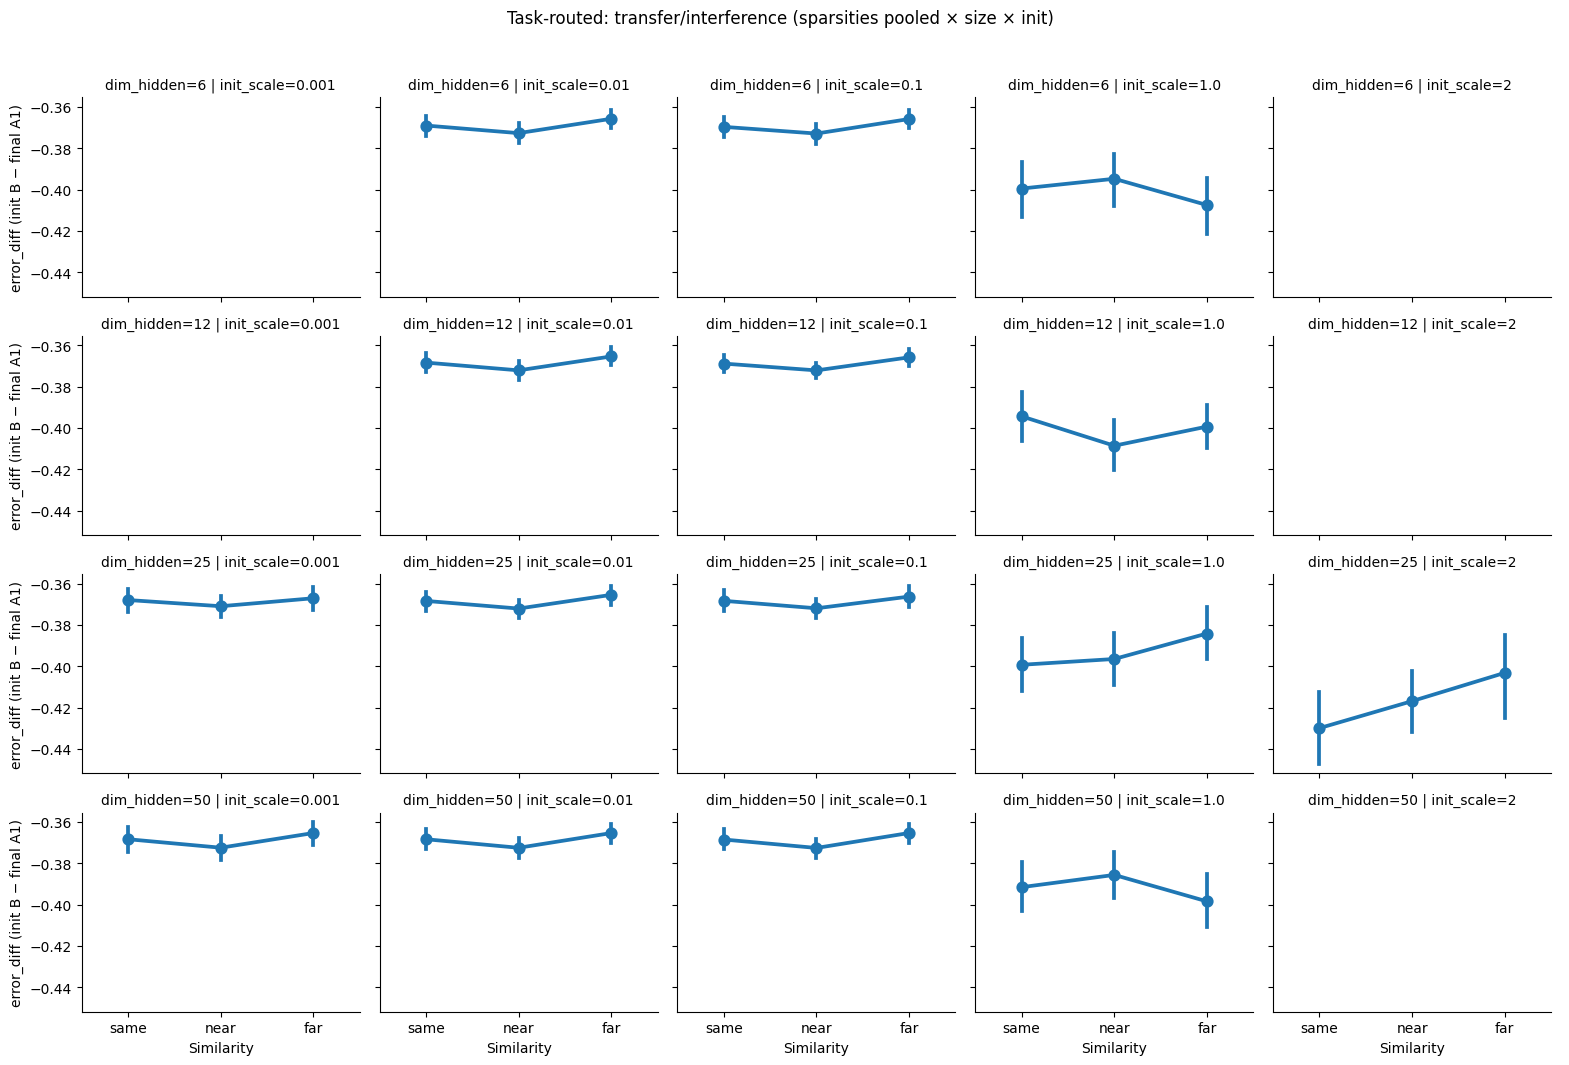

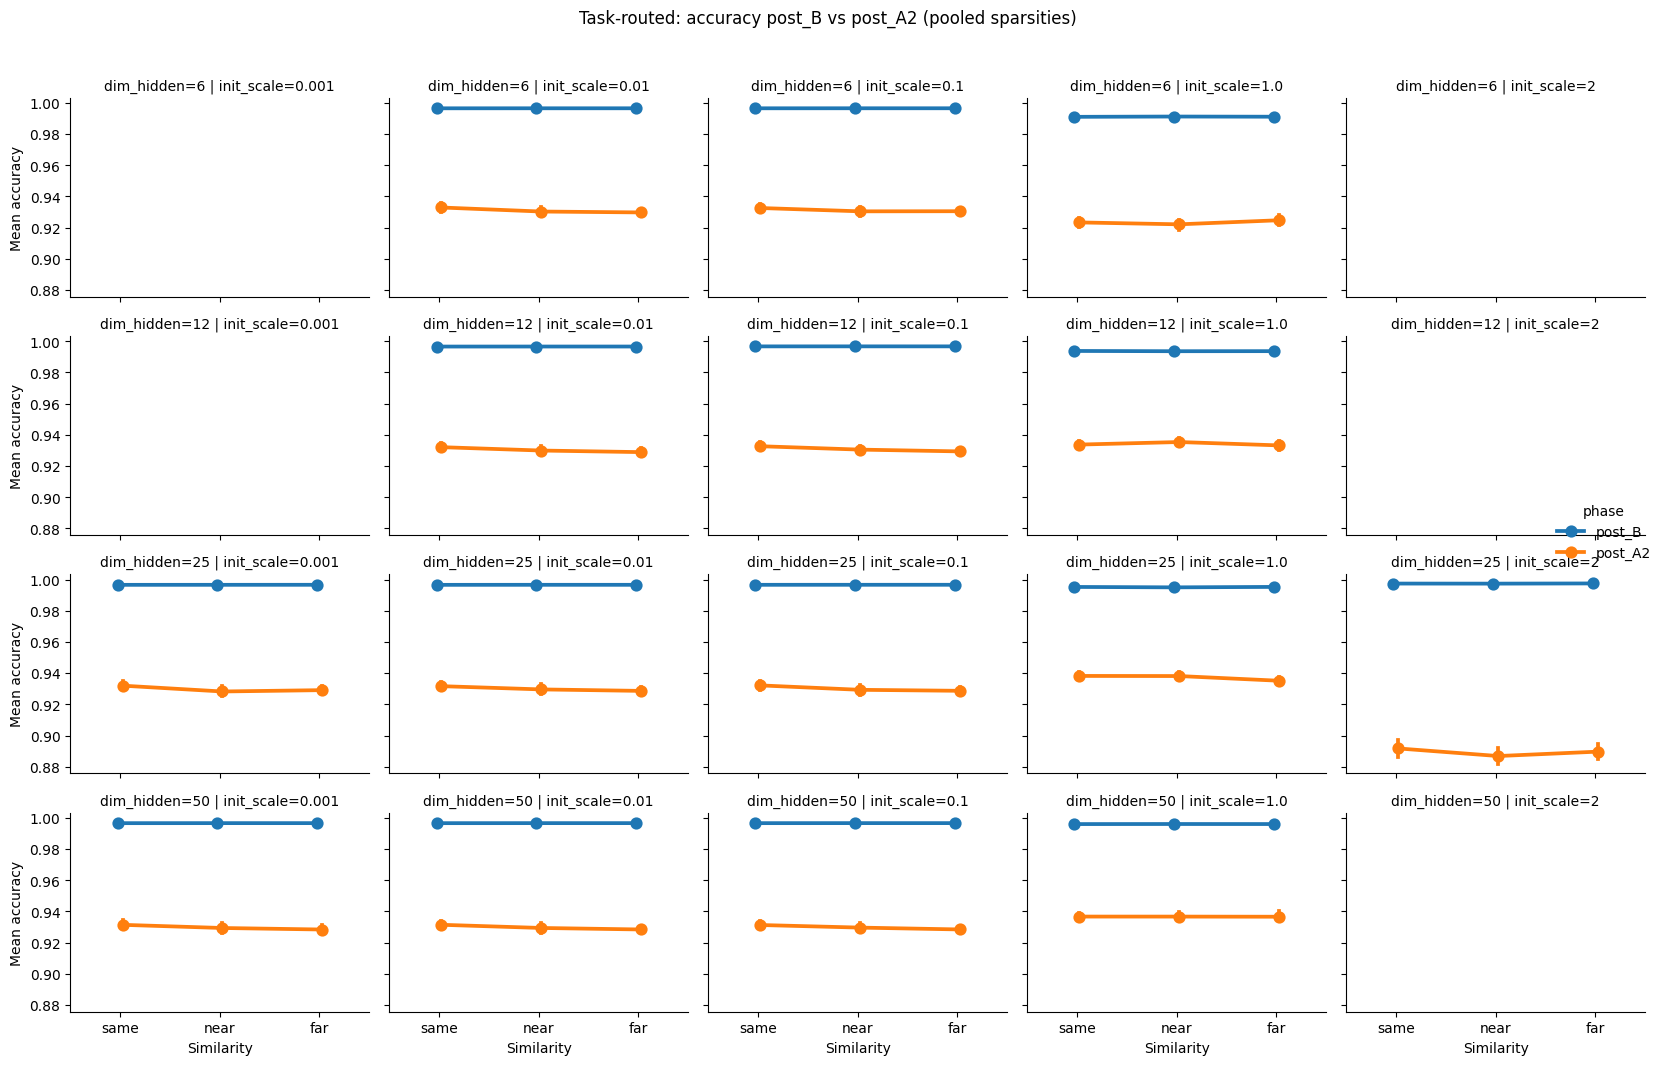

In [10]:
def _facet_orders():
    init_order = [s for s in PAPER_INIT_SCALES if s in INIT_SCALE_ORDER]
    return init_order


init_order = _facet_orders()
dim_order = list(SIZE_GRID)

if not transfer_task.empty:
    tr = transfer_task.copy()
    tr["init_scale"] = tr["init_scale"].astype(float)
    g = sns.catplot(
        data=tr,
        x="condition",
        y="error_diff",
        col="init_scale",
        row="dim_hidden",
        col_order=init_order,
        row_order=dim_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "error_diff (init B − final A1)")
    g.set_titles(row_template="dim_hidden={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: paper-faithful transfer (sparsities pooled × size × init)", y=1.02)
    plt.tight_layout()
    plt.show()

if not acc_task.empty:
    sub = acc_task[acc_task["phase"].isin(["post_B", "post_A2"])].copy()
    sub["init_scale"] = sub["init_scale"].astype(float)
    g = sns.catplot(
        data=sub,
        x="condition",
        y="mean_accuracy",
        hue="phase",
        col="init_scale",
        row="dim_hidden",
        col_order=init_order,
        row_order=dim_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=["post_B", "post_A2"],
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "Mean accuracy")
    g.set_titles(row_template="dim_hidden={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: accuracy post_B vs post_A2 (pooled sparsities)", y=1.02)
    plt.tight_layout()
    plt.show()


## Figure 2 (size summary): Principal angles (task-routed)

Aggregate mean ± SEM within each (dim_hidden, init_scale, condition), pooling sparsities.


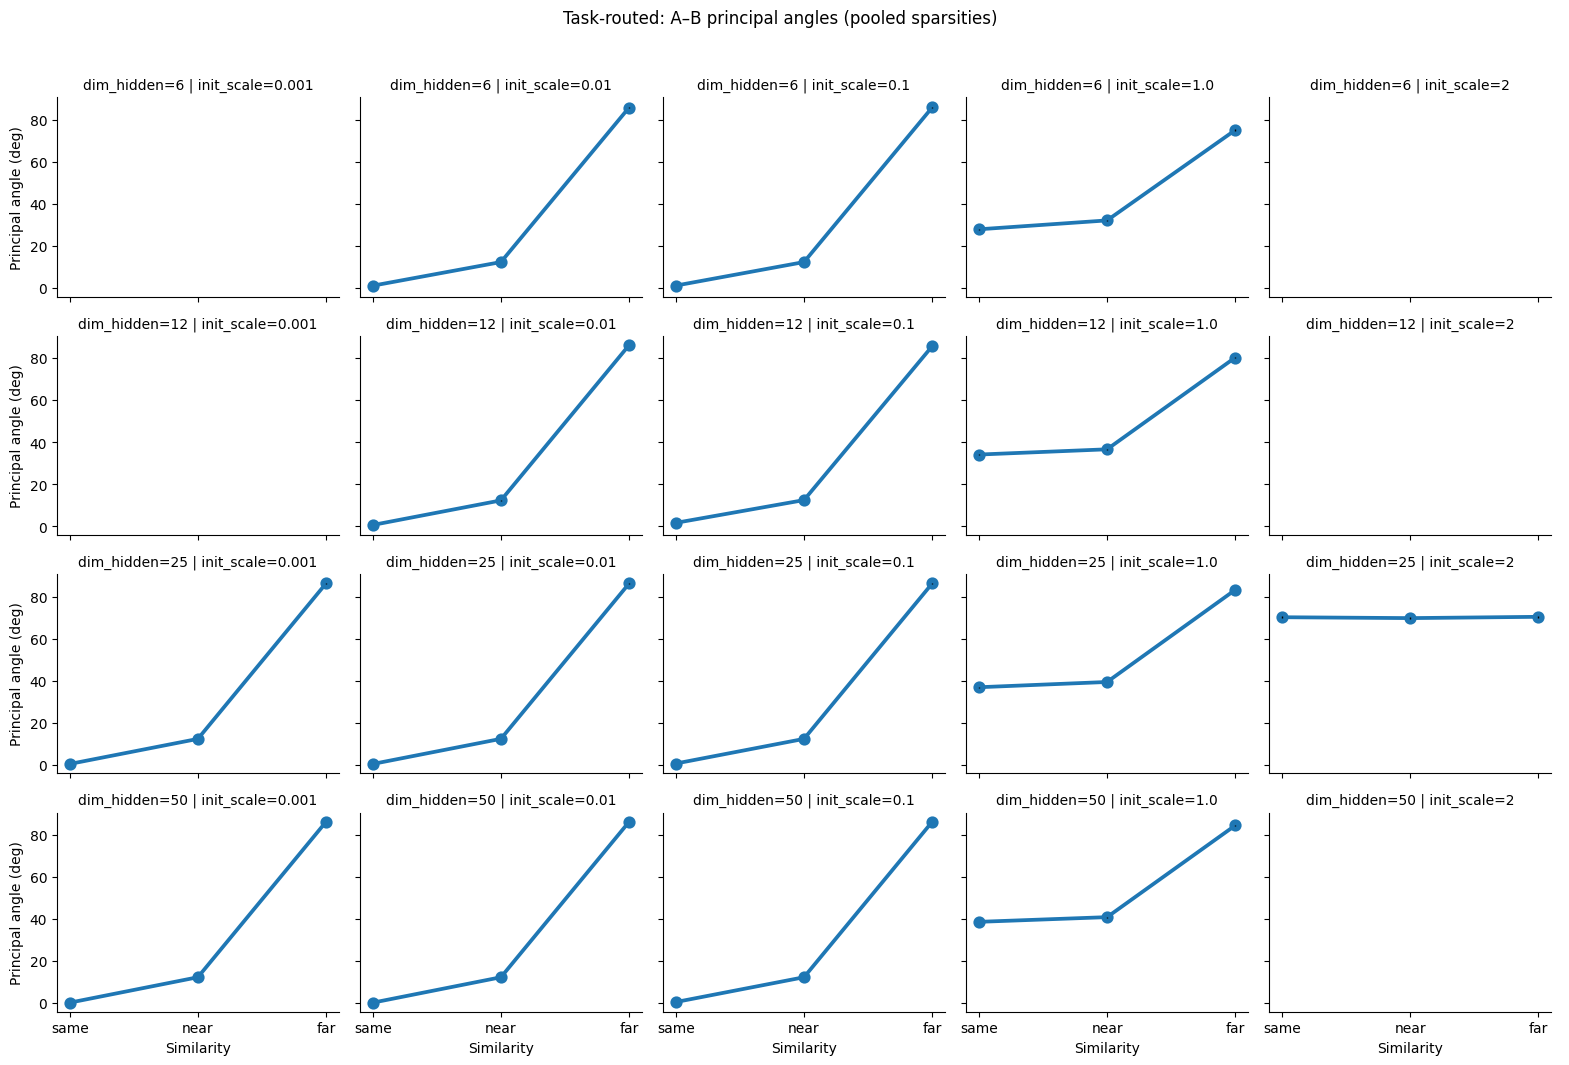

In [11]:
if not angles_task.empty:
    ang = angles_task.copy()
    ang["init_scale"] = ang["init_scale"].astype(float)

    # Index-as grouper + reset_index avoids pandas categorical + as_index=False/named-agg bug
    ang_agg = (
        ang.groupby(["dim_hidden", "init_scale", "condition"], observed=True)["principal_angle_between"]
        .agg(["mean", "sem"])
        .reset_index()
    )
    ang_agg = ang_agg.rename(columns={"mean": "angle_mean", "sem": "angle_sem"})

    g = sns.catplot(
        data=ang_agg,
        x="condition",
        y="angle_mean",
        col="init_scale",
        row="dim_hidden",
        col_order=init_order,
        row_order=dim_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        height=2.6,
        aspect=1.2,
    )

    pairs = [(dh, isc) for dh in dim_order for isc in init_order]
    for ax, (dh, isc) in zip(g.axes.flat, pairs):
        subdf = ang_agg[
            (ang_agg["dim_hidden"] == dh) & (np.isclose(ang_agg["init_scale"].astype(float), float(isc)))
        ]
        subdf = subdf.set_index("condition").reindex(SIMILARITY_ORDER)
        x = np.arange(len(SIMILARITY_ORDER))
        ax.errorbar(x, subdf["angle_mean"].values, yerr=subdf["angle_sem"].values, fmt="none", c="black", lw=1)

    g.set_axis_labels("Similarity", "Principal angle (deg)")
    g.set_titles(row_template="dim_hidden={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: A–B principal angles (pooled sparsities)", y=1.02)
    plt.tight_layout()
    plt.show()


## Figure 3 (size summary): PC count (99% variance, combined pathway)

Participant-level `n_pcs_99` over pooled sparsities, with mean ± SEM shown by bar + errorbar, facet by size × init.


In [12]:
if not rep_task.empty:
    pc = rep_task[(rep_task["pathway"] == "combined")].copy()
    pc["init_scale"] = pc["init_scale"].astype(float)
    pc["phase"] = pd.Categorical(pc["phase"], categories=PHASE_ORDER, ordered=True)
    pc["condition"] = pd.Categorical(pc["condition"], categories=SIMILARITY_ORDER, ordered=True)

    phase_labels = {"post_A": "Post A", "post_B": "Post B", "post_A2": "Post A2"}
    cond_labels = {"same": "Same", "near": "Near", "far": "Far"}

    pc = pc[pc["sparsity_label"].isin(PAPER_SPARSITIES)].copy()
    if pc.empty or "n_pcs_99" not in pc.columns:
        print("No rep rows for PC count summary.")
    else:
        pc["phase_plot"] = pc["phase"].map(phase_labels)
        pc["condition_plot"] = pc["condition"].map(cond_labels)

        g = sns.catplot(
            data=pc,
            x="condition_plot",
            y="n_pcs_99",
            hue="phase_plot",
            col="init_scale",
            row="dim_hidden",
            col_order=init_order,
            row_order=size_order,
            kind="bar",
            order=["Same", "Near", "Far"],
            hue_order=["Post A", "Post B", "Post A2"],
            palette="Set2",
            height=2.6,
            aspect=1.15,
            legend_out=False,
            errorbar="se",
            capsize=0.04,
        )
        g.set_axis_labels("Task similarity", "# PCs (99% var.)")
        g.set_titles(row_template="size={row_name}", col_template="init_scale={col_name}")
        if g._legend is not None:
            g._legend.set_title("Phase")
        g.fig.suptitle("Task-routed: PC count (99% var., combined pathway) — pooled sparsities (mean ± SEM)", y=1.04)
        plt.tight_layout()
        plt.show()


NameError: name 'size_order' is not defined

## Figure 4 + appendix: PCA geometry (2D and 3D)

Uses **GEOMETRY_SPARSITY = `1.0`** only (see setup cell). Outer loop: **dim_hidden**; inner: **init_scale**.


No candidate run found 6 1.0 0.001


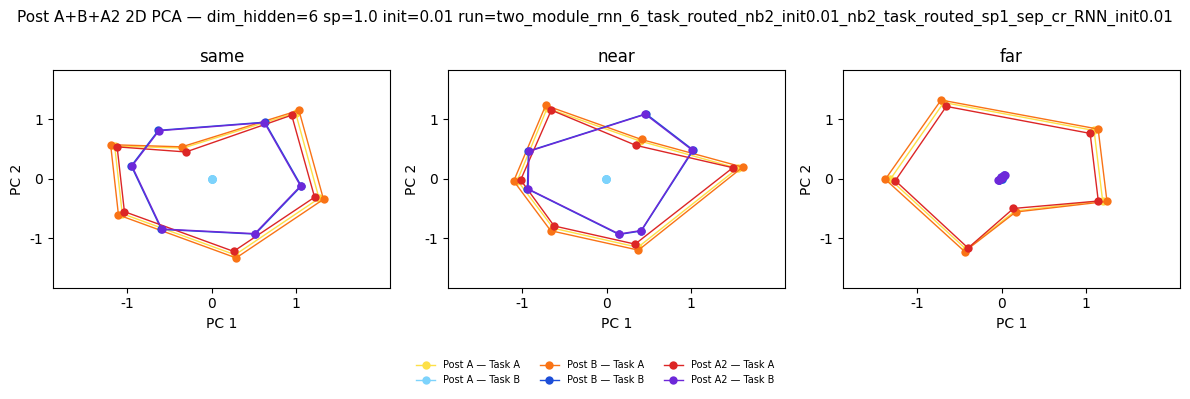

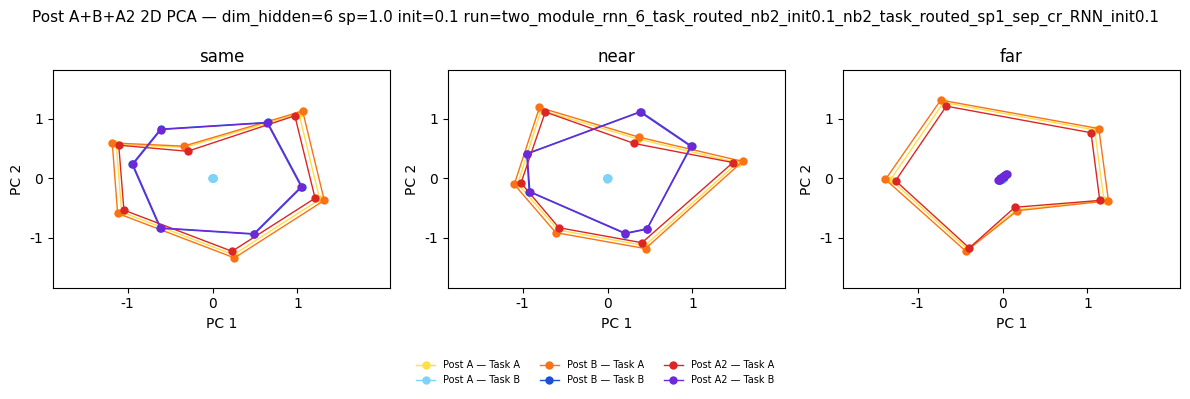

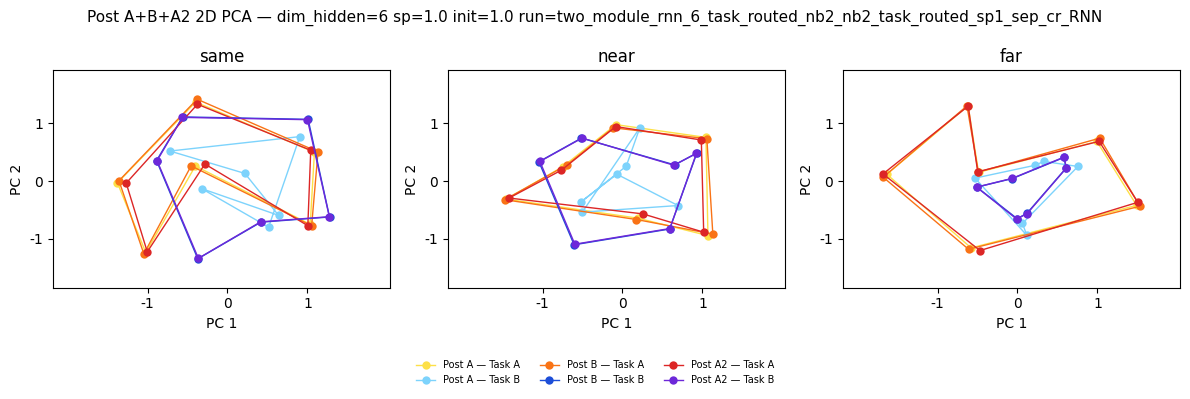

No candidate run found 6 1.0 2.0
No candidate run found 12 1.0 0.001


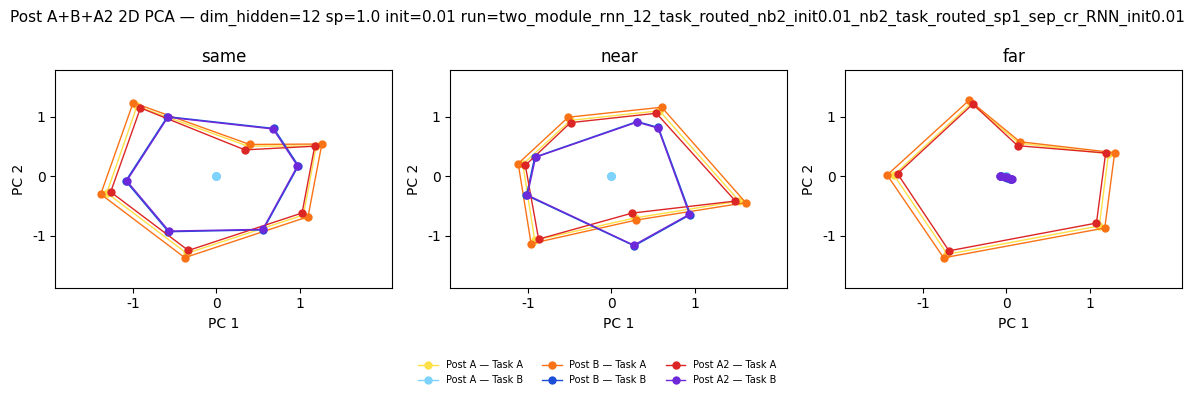

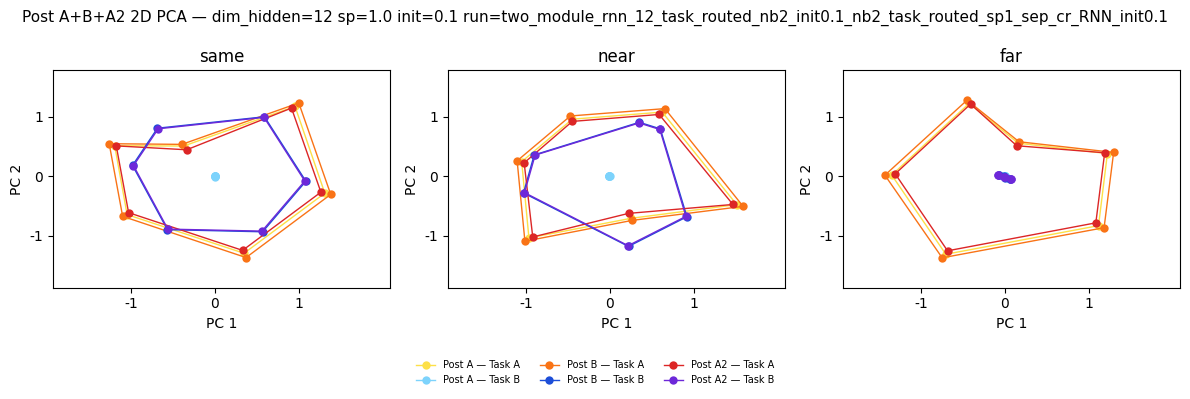

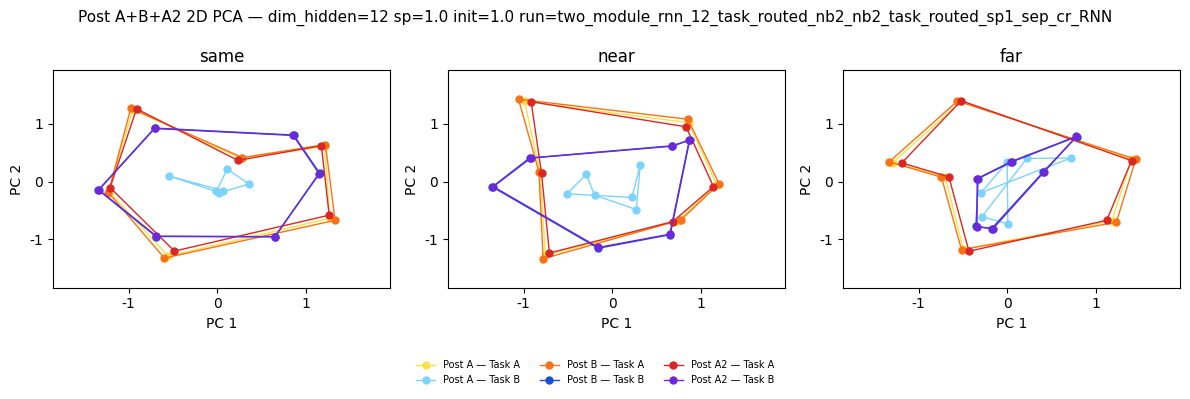

No candidate run found 12 1.0 2.0


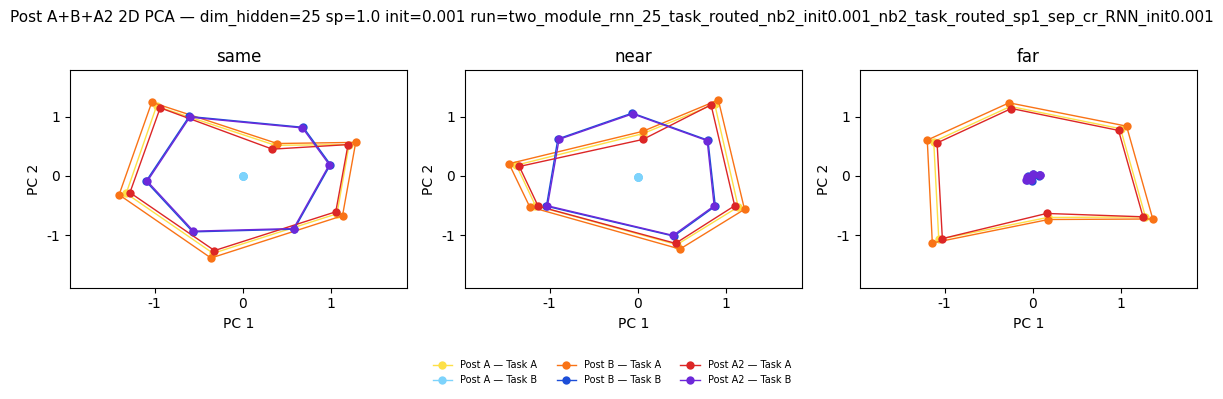

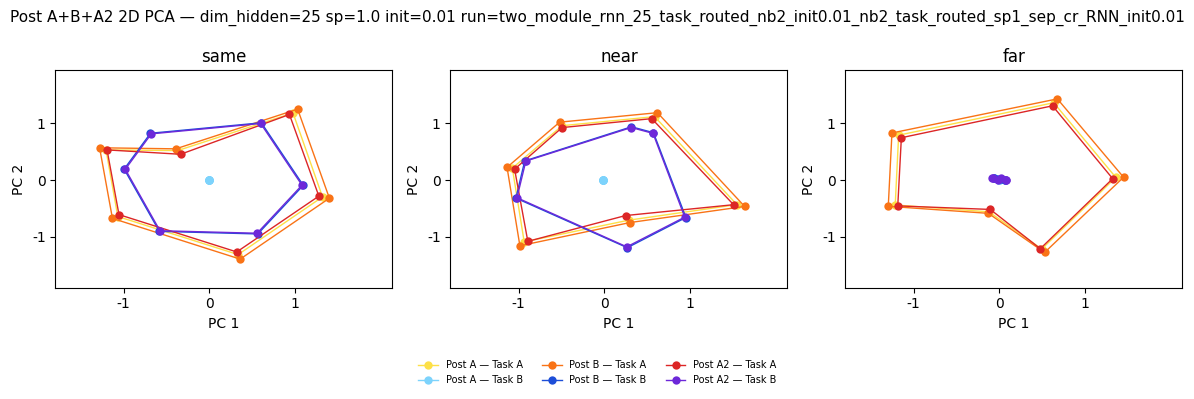

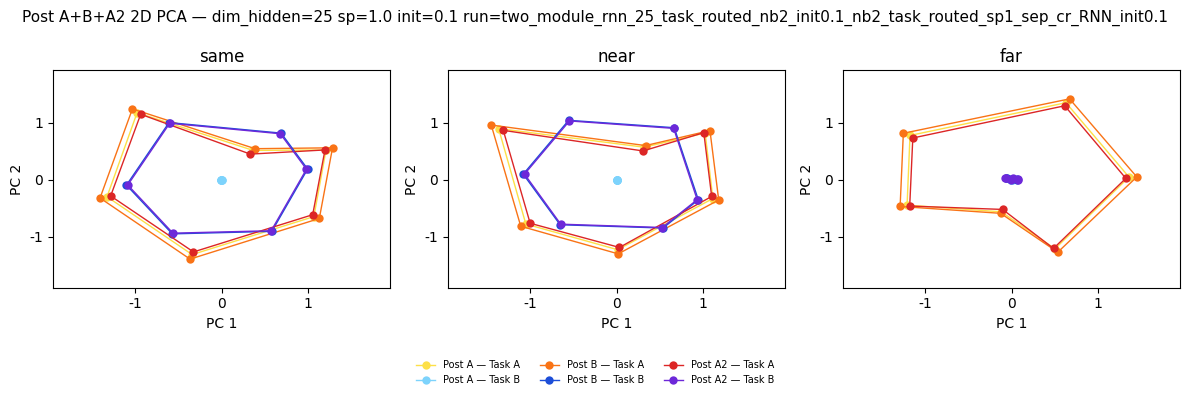

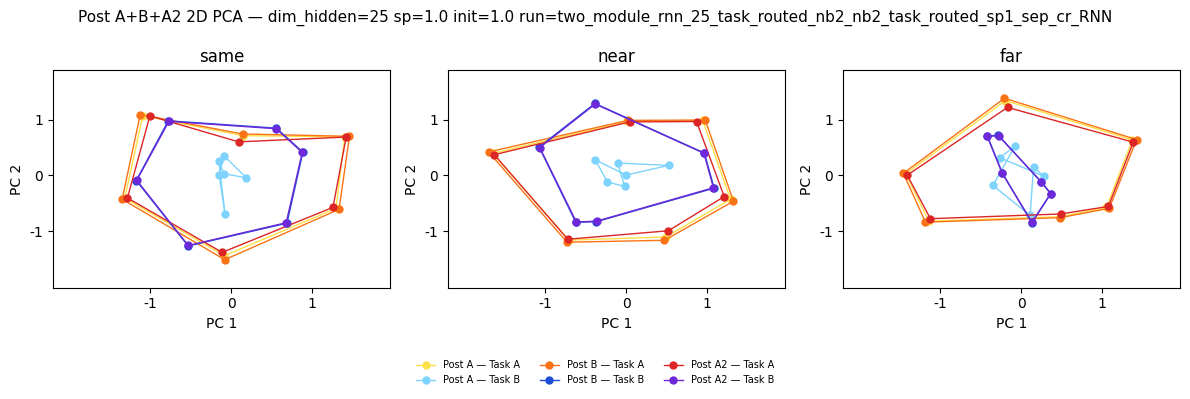

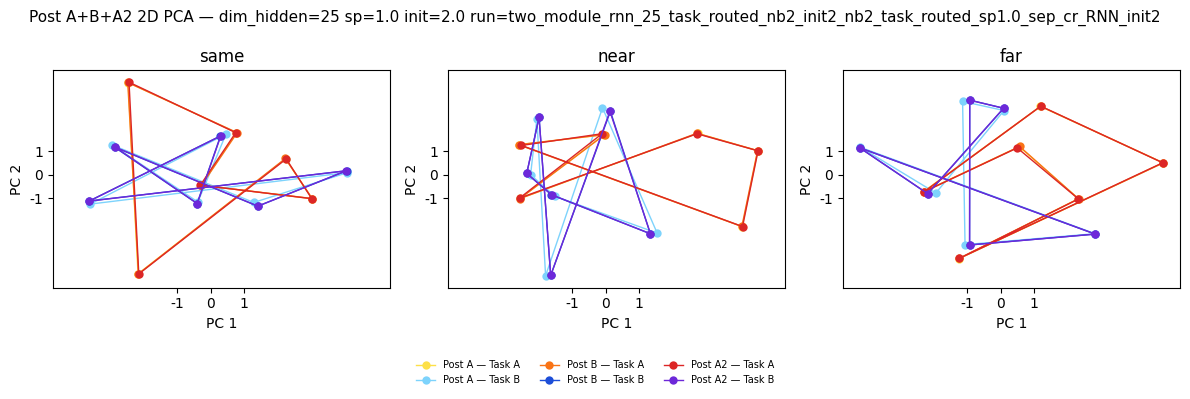

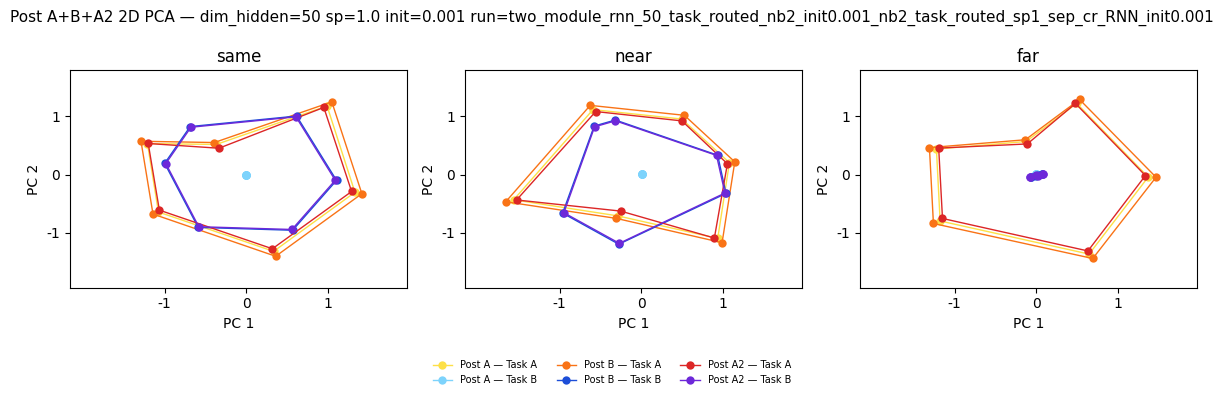

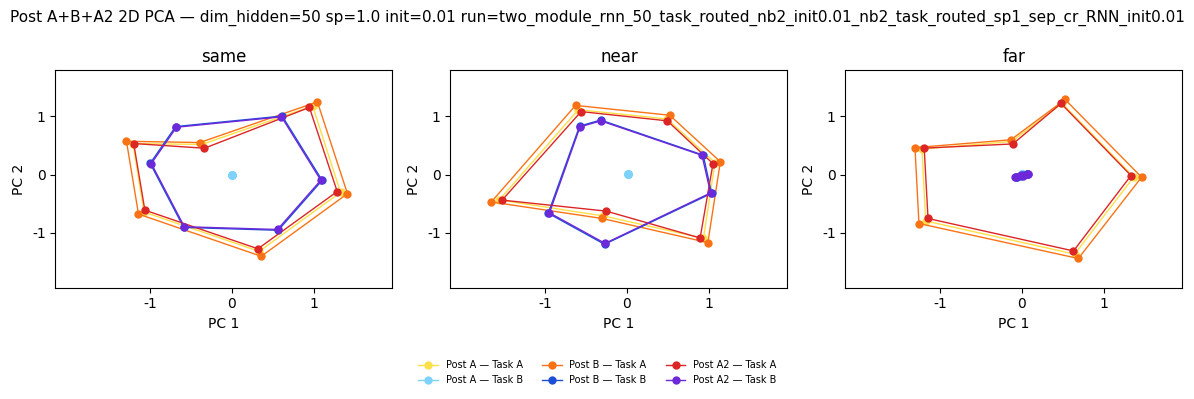

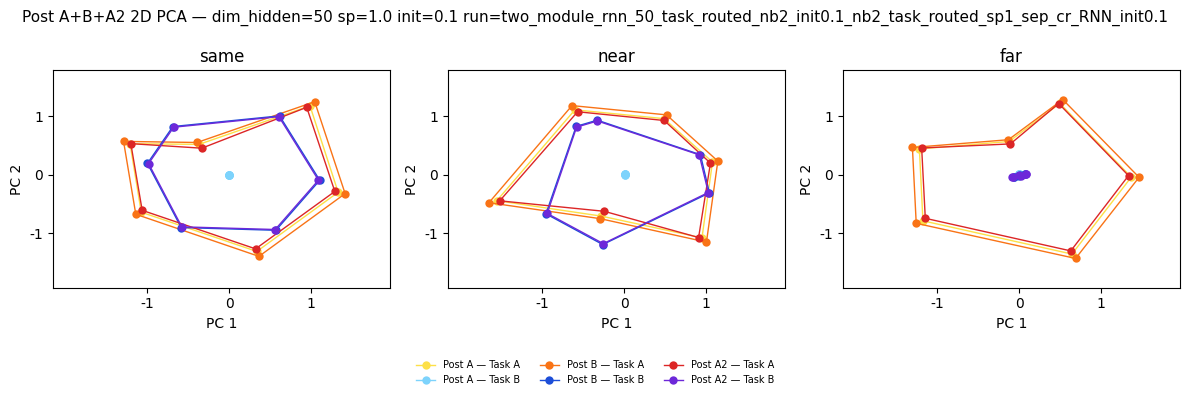

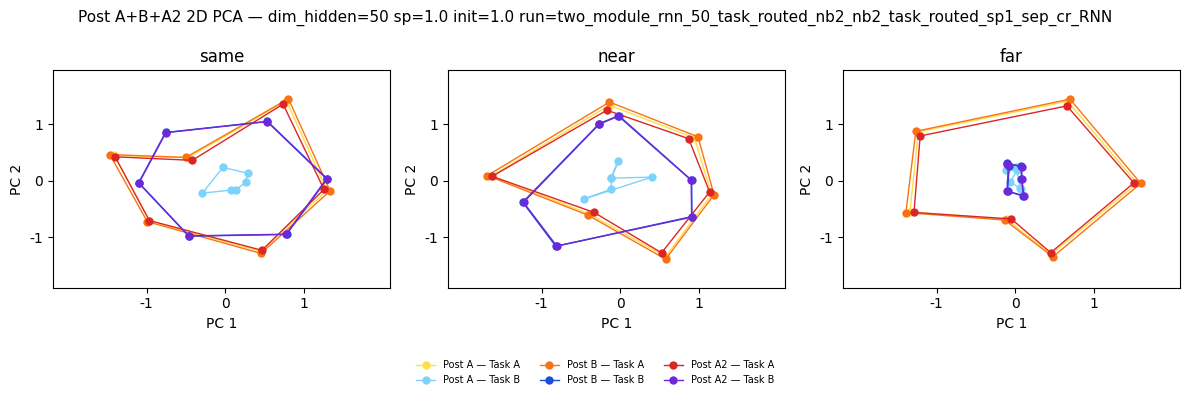

No candidate run found 50 1.0 2.0
No candidate run found 6 1.0 0.001


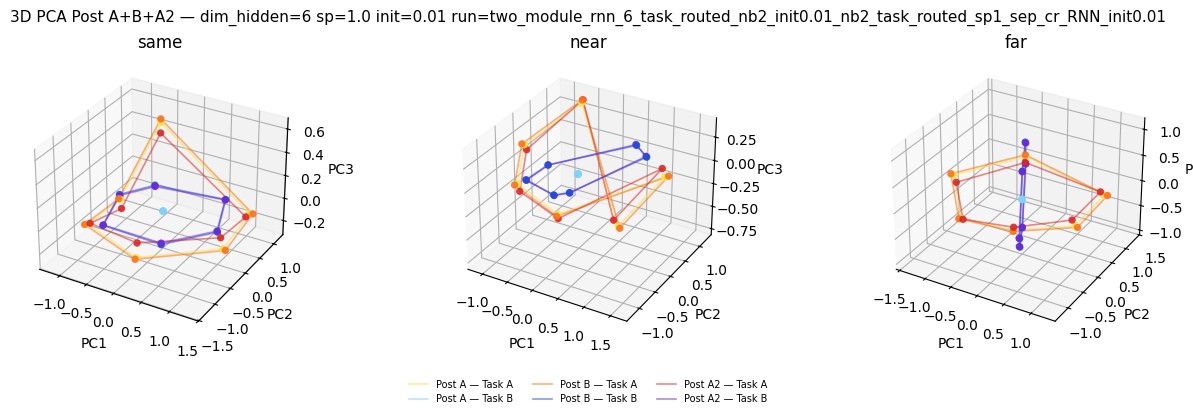

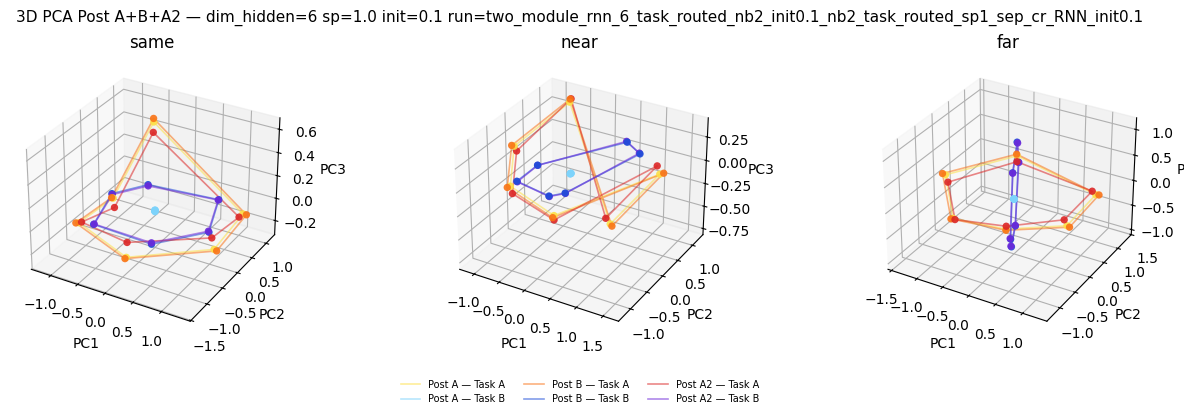

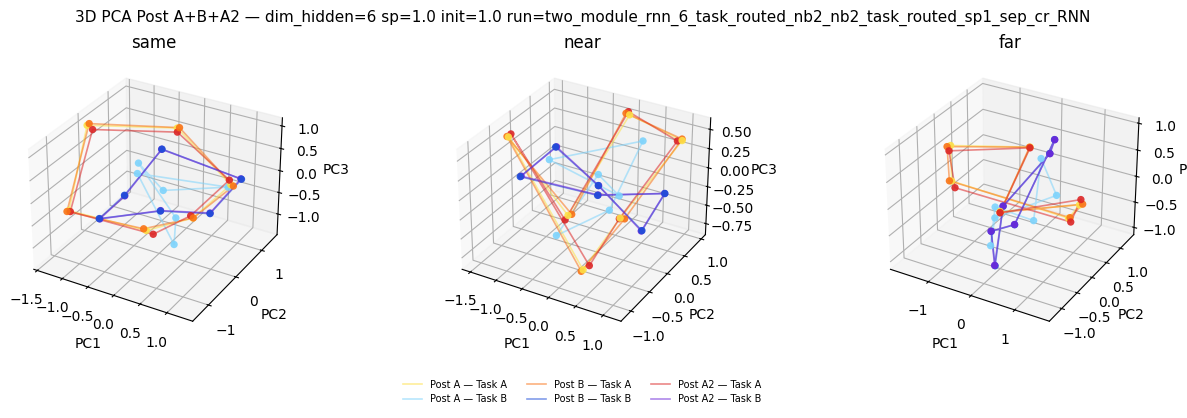

No candidate run found 6 1.0 2.0
No candidate run found 12 1.0 0.001


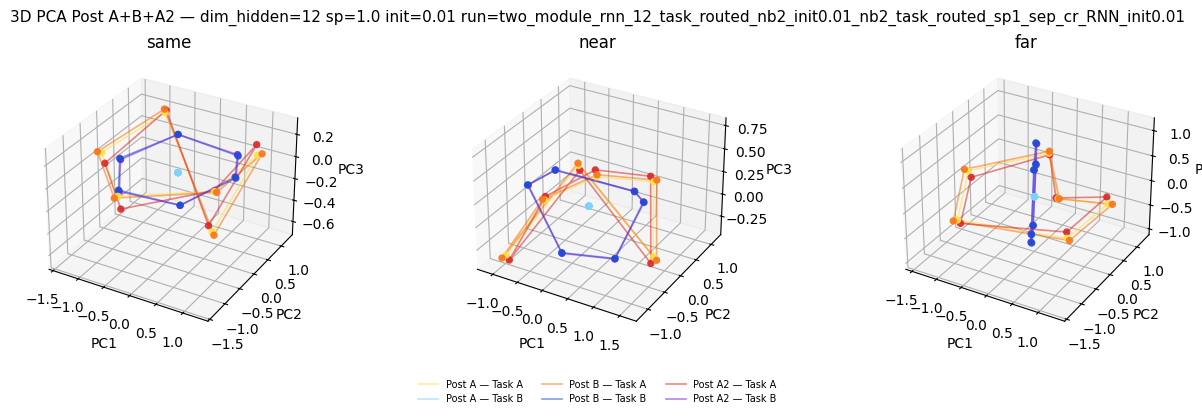

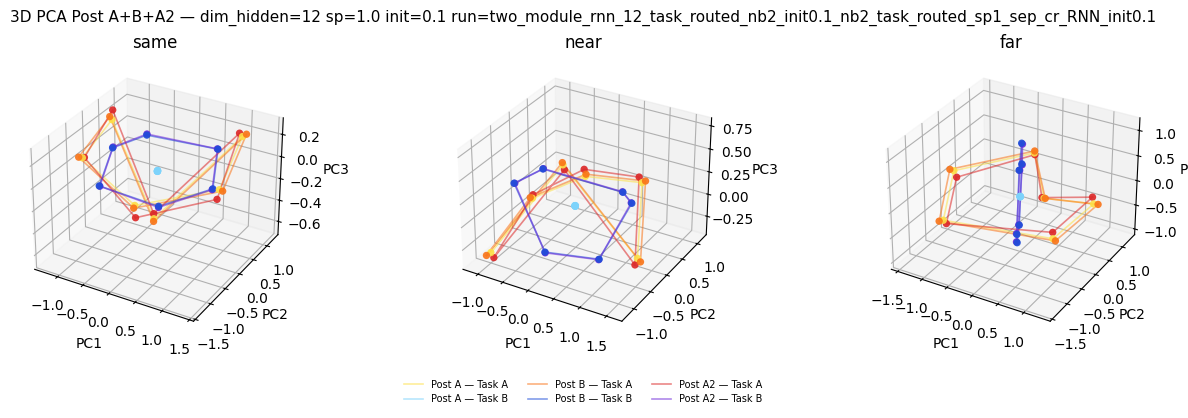

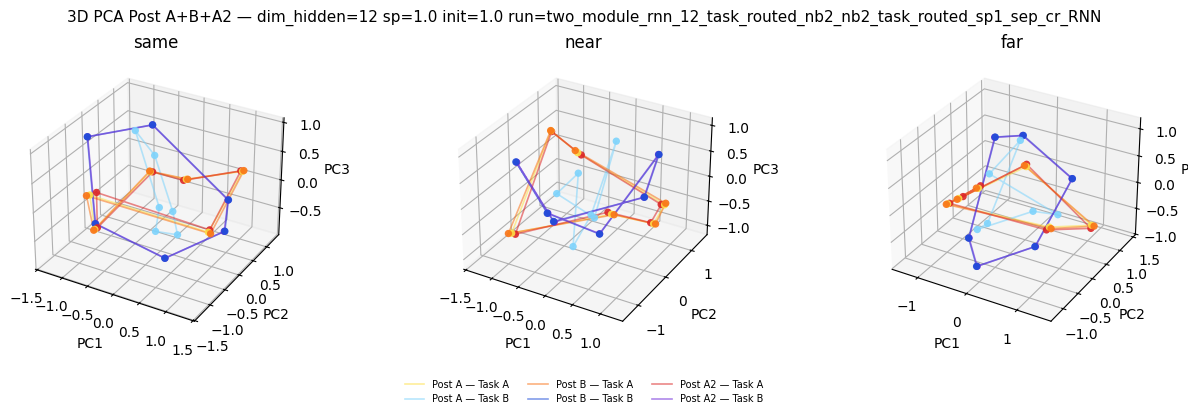

No candidate run found 12 1.0 2.0


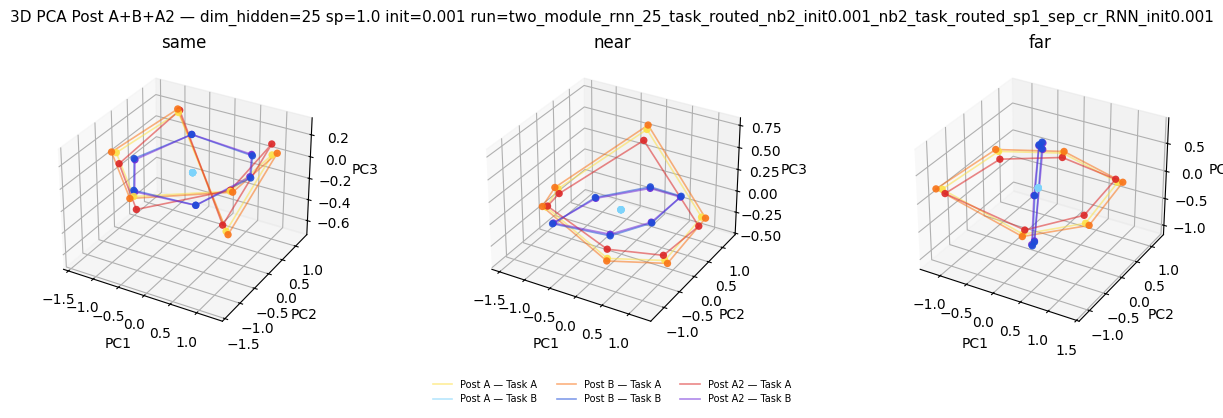

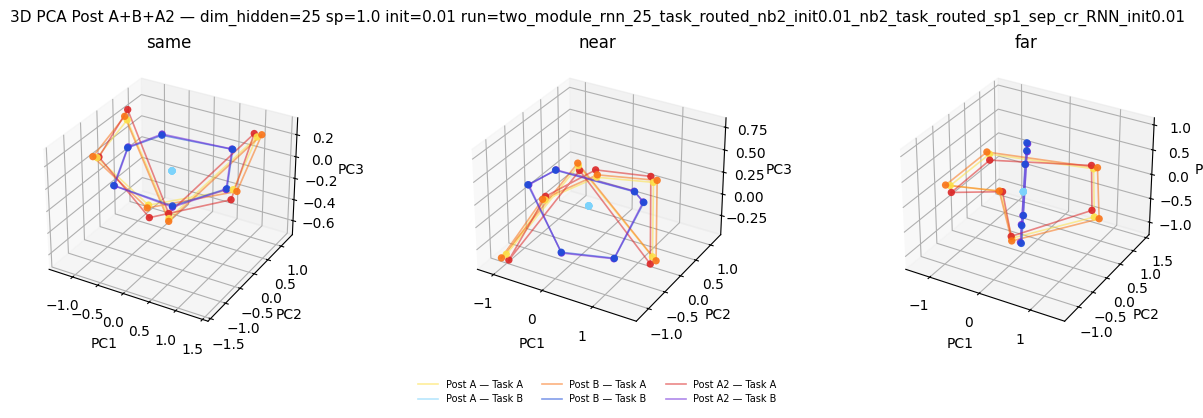

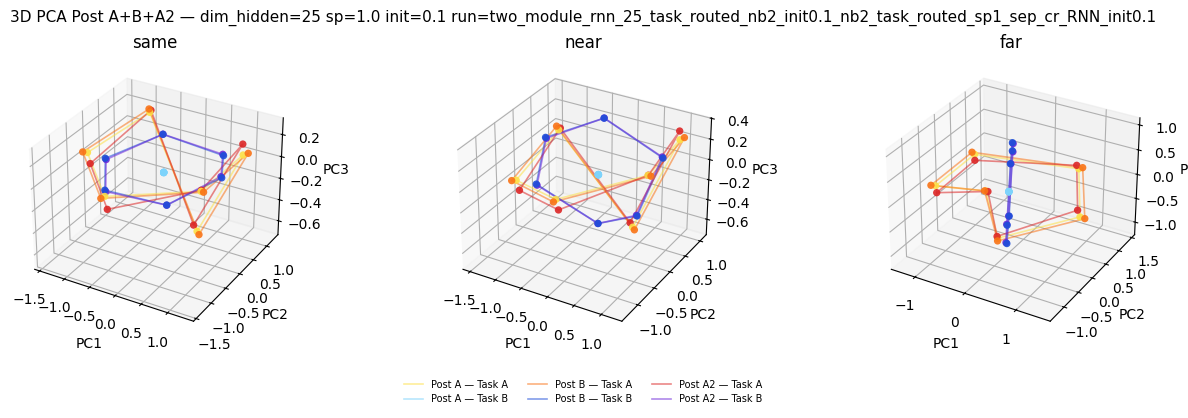

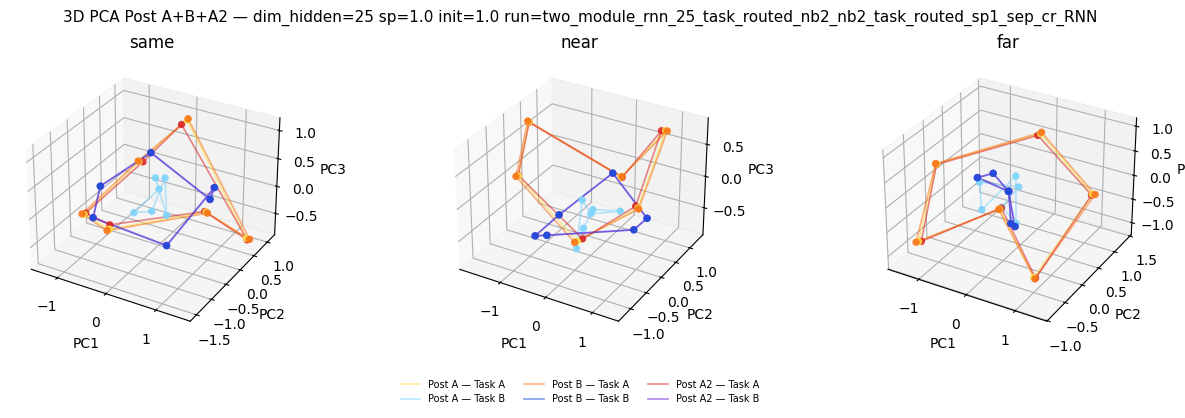

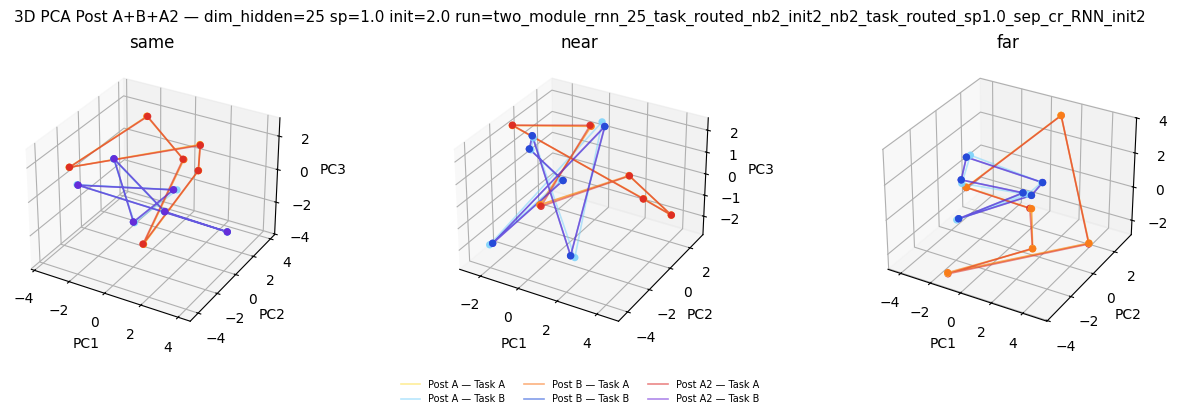

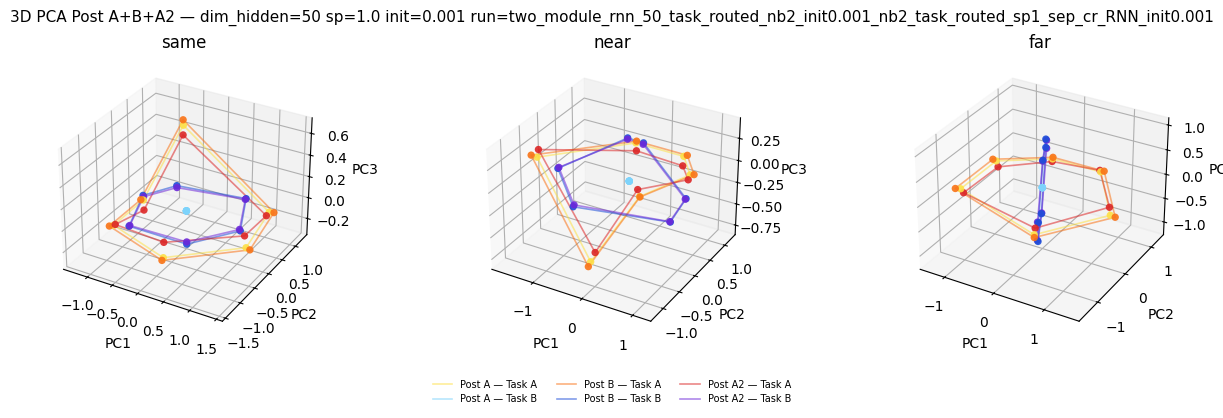

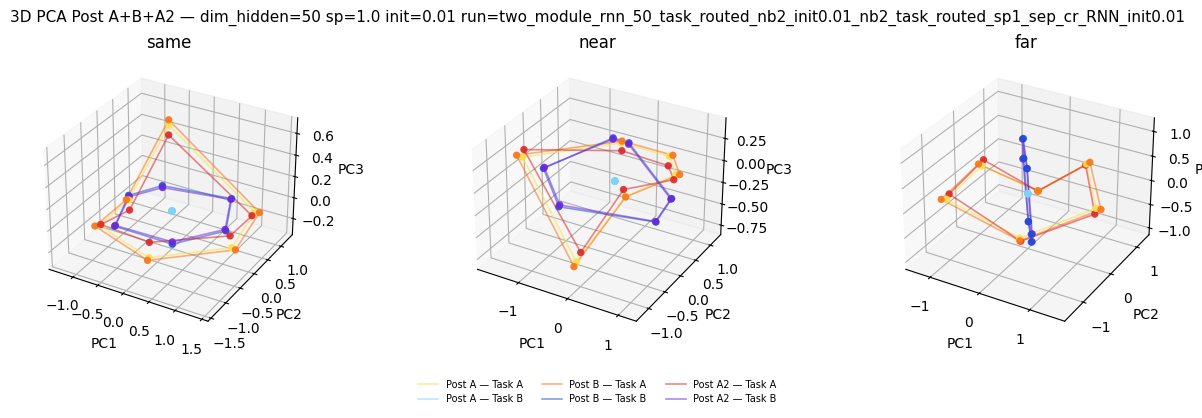

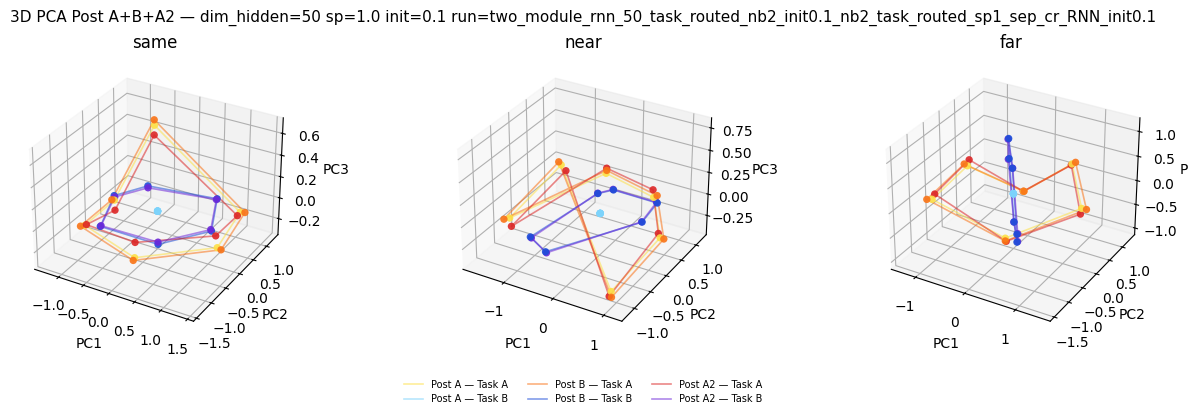

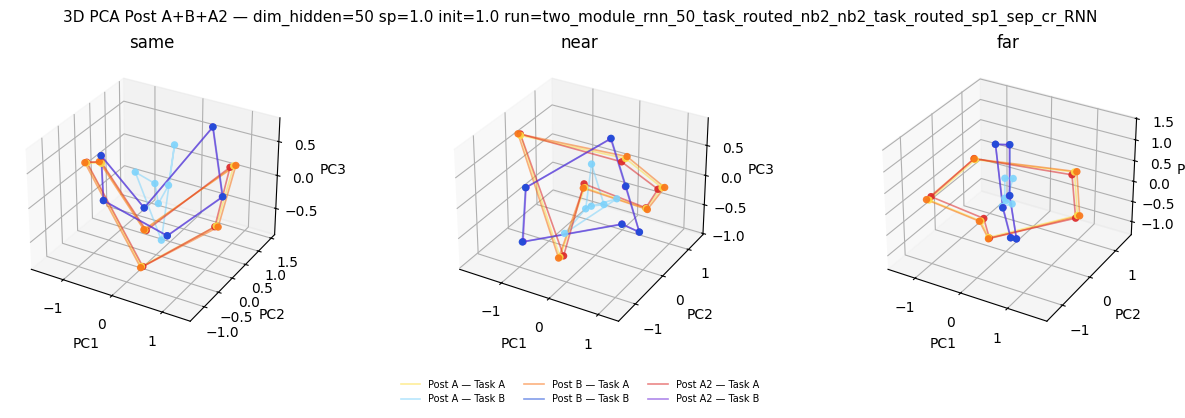

No candidate run found 50 1.0 2.0


In [ ]:
from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2_3d


def plot_geometry_snapshot(all_ann_data: dict, dim_h: int, target_sp: str, target_init: float, n_stim_plot: int = 12):
    candidates = [
        (rid, b) for rid, b in all_ann_data.items()
        if str(b["sparsity_label"]) == str(target_sp) and float(b["init_scale"]) == float(target_init)
    ]
    if not candidates:
        print("No candidate run found", dim_h, target_sp, target_init)
        return

    run_id, bundle = candidates[0]
    ann_data = bundle["data"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(
        f"Post A+B+A2 2D PCA — dim_hidden={dim_h} sp={target_sp} init={target_init} run={run_id}",
        fontsize=11,
    )

    all_triples = []
    for cond in SIMILARITY_ORDER:
        entries = ann_data.get(cond, [])
        if not entries:
            all_triples.append(None)
            continue
        entry = entries[0]
        raw_A = entry.get("hiddens_post_phase_0")
        raw_B = entry.get("hiddens_post_phase_1")
        raw_A2 = entry.get("hiddens_post_phase_2")
        if raw_A is None or raw_B is None or raw_A2 is None:
            all_triples.append(None)
            continue
        h_A = np.asarray(raw_A)
        h_B = np.asarray(raw_B)
        h_A2 = np.asarray(raw_A2)
        if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
            all_triples.append(None)
            continue
        if h_A.shape[0] < n_stim_plot or h_B.shape[0] < n_stim_plot or h_A2.shape[0] < n_stim_plot:
            all_triples.append(None)
            continue
        h_A = h_A[:n_stim_plot]
        h_B = h_B[:n_stim_plot]
        h_A2 = h_A2[:n_stim_plot]
        _, X2_A, X2_B, X2_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=2)
        all_triples.append((X2_A, X2_B, X2_A2))

    flat = []
    for triple in all_triples:
        if triple is not None:
            X2_A, X2_B, X2_A2 = triple
            flat.extend([X2_A, X2_B, X2_A2])
    lims_global = get_axis_limits(np.vstack(flat)) if flat else {}

    for ax, cond, triple in zip(axes, SIMILARITY_ORDER, all_triples):
        if triple is None:
            ax.set_title(f"{cond} (no data)")
            ax.axis("off")
            continue
        X2_A, X2_B, X2_A2 = triple
        plot_split_stim_postA_postB_postA2(ax, X2_A, X2_B, X2_A2, lims_global)
        ax.set_title(cond)

    plt.tight_layout(rect=[0, 0.14, 1, 1])
    for ax in axes:
        hs, ls = ax.get_legend_handles_labels()
        if hs:
            fig.legend(hs, ls, loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False, fontsize=7)
            break
    plt.show()


def plot_geometry_snapshot_3d(all_ann_data: dict, dim_h: int, target_sp: str, target_init: float, n_stim_plot: int = 12):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    candidates = [
        (rid, b) for rid, b in all_ann_data.items()
        if str(b["sparsity_label"]) == str(target_sp) and float(b["init_scale"]) == float(target_init)
    ]
    if not candidates:
        print("No candidate run found", dim_h, target_sp, target_init)
        return

    run_id, bundle = candidates[0]
    ann_data = bundle["data"]

    fig = plt.figure(figsize=(13, 4.2))
    fig.suptitle(
        f"3D PCA Post A+B+A2 — dim_hidden={dim_h} sp={target_sp} init={target_init} run={run_id}",
        fontsize=11,
    )

    legend_handles = None
    for i, cond in enumerate(SIMILARITY_ORDER, start=1):
        ax = fig.add_subplot(1, 3, i, projection="3d")
        entries = ann_data.get(cond, [])
        if not entries:
            ax.set_title(f"{cond} (no data)")
            continue

        entry = entries[0]
        raw_A = entry.get("hiddens_post_phase_0")
        raw_B = entry.get("hiddens_post_phase_1")
        raw_A2 = entry.get("hiddens_post_phase_2")
        if raw_A is None or raw_B is None or raw_A2 is None:
            ax.set_title(f"{cond} (insufficient)")
            continue
        h_A = np.asarray(raw_A)
        h_B = np.asarray(raw_B)
        h_A2 = np.asarray(raw_A2)
        if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
            ax.set_title(f"{cond} (insufficient)")
            continue
        if h_A.shape[0] < n_stim_plot or h_B.shape[0] < n_stim_plot or h_A2.shape[0] < n_stim_plot:
            ax.set_title(f"{cond} (insufficient)")
            continue

        h_A = h_A[:n_stim_plot]
        h_B = h_B[:n_stim_plot]
        h_A2 = h_A2[:n_stim_plot]
        _, X3_A, X3_B, X3_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=3)

        with_leg = legend_handles is None
        h = plot_split_stim_postA_postB_postA2_3d(ax, X3_A, X3_B, X3_A2, labels_for_legend=with_leg)
        if legend_handles is None and h:
            legend_handles = h

        ax.set_title(cond)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")

    if legend_handles:
        fig.legend(
            legend_handles,
            [ln.get_label() for ln in legend_handles],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            frameon=False,
            fontsize=7,
        )

    plt.tight_layout(rect=[0, 0.16, 1, 1])
    plt.show()


for h in SIZE_GRID:
    geom_df = size_bundles[h]["task_df"]
    geom_df = geom_df[geom_df["sparsity_label"].astype(str) == str(GEOMETRY_SPARSITY)]
    all_geom = load_all_ann_data(geom_df)
    for init_scale in PAPER_INIT_SCALES:
        plot_geometry_snapshot(all_geom, dim_h=h, target_sp=GEOMETRY_SPARSITY, target_init=float(init_scale))

for h in SIZE_GRID:
    geom_df = size_bundles[h]["task_df"]
    geom_df = geom_df[geom_df["sparsity_label"].astype(str) == str(GEOMETRY_SPARSITY)]
    all_geom = load_all_ann_data(geom_df)
    for init_scale in PAPER_INIT_SCALES:
        plot_geometry_snapshot_3d(all_geom, dim_h=h, target_sp=GEOMETRY_SPARSITY, target_init=float(init_scale))


## Figure 5 (size summary): Task-routed vs shared vs single-module baseline

No `broadcast_baseline_sparsity` triplication (single-module rows appear once per size; catplot pools with task/shared by size).


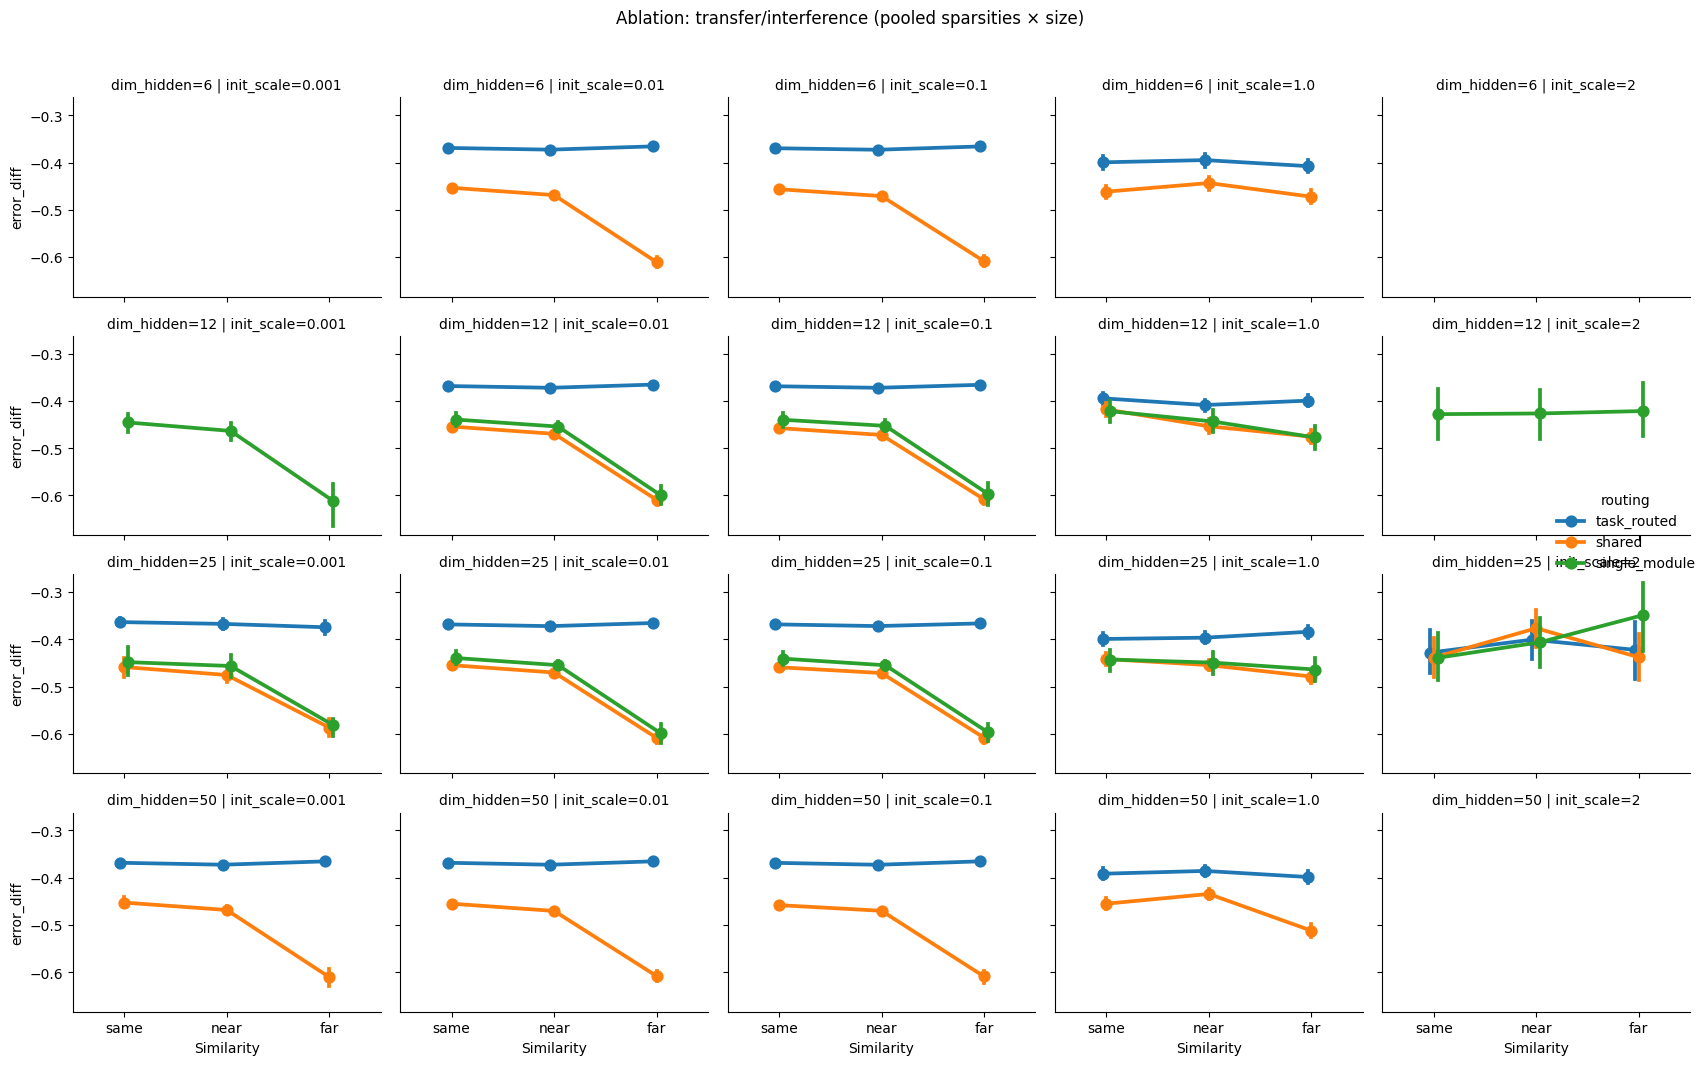

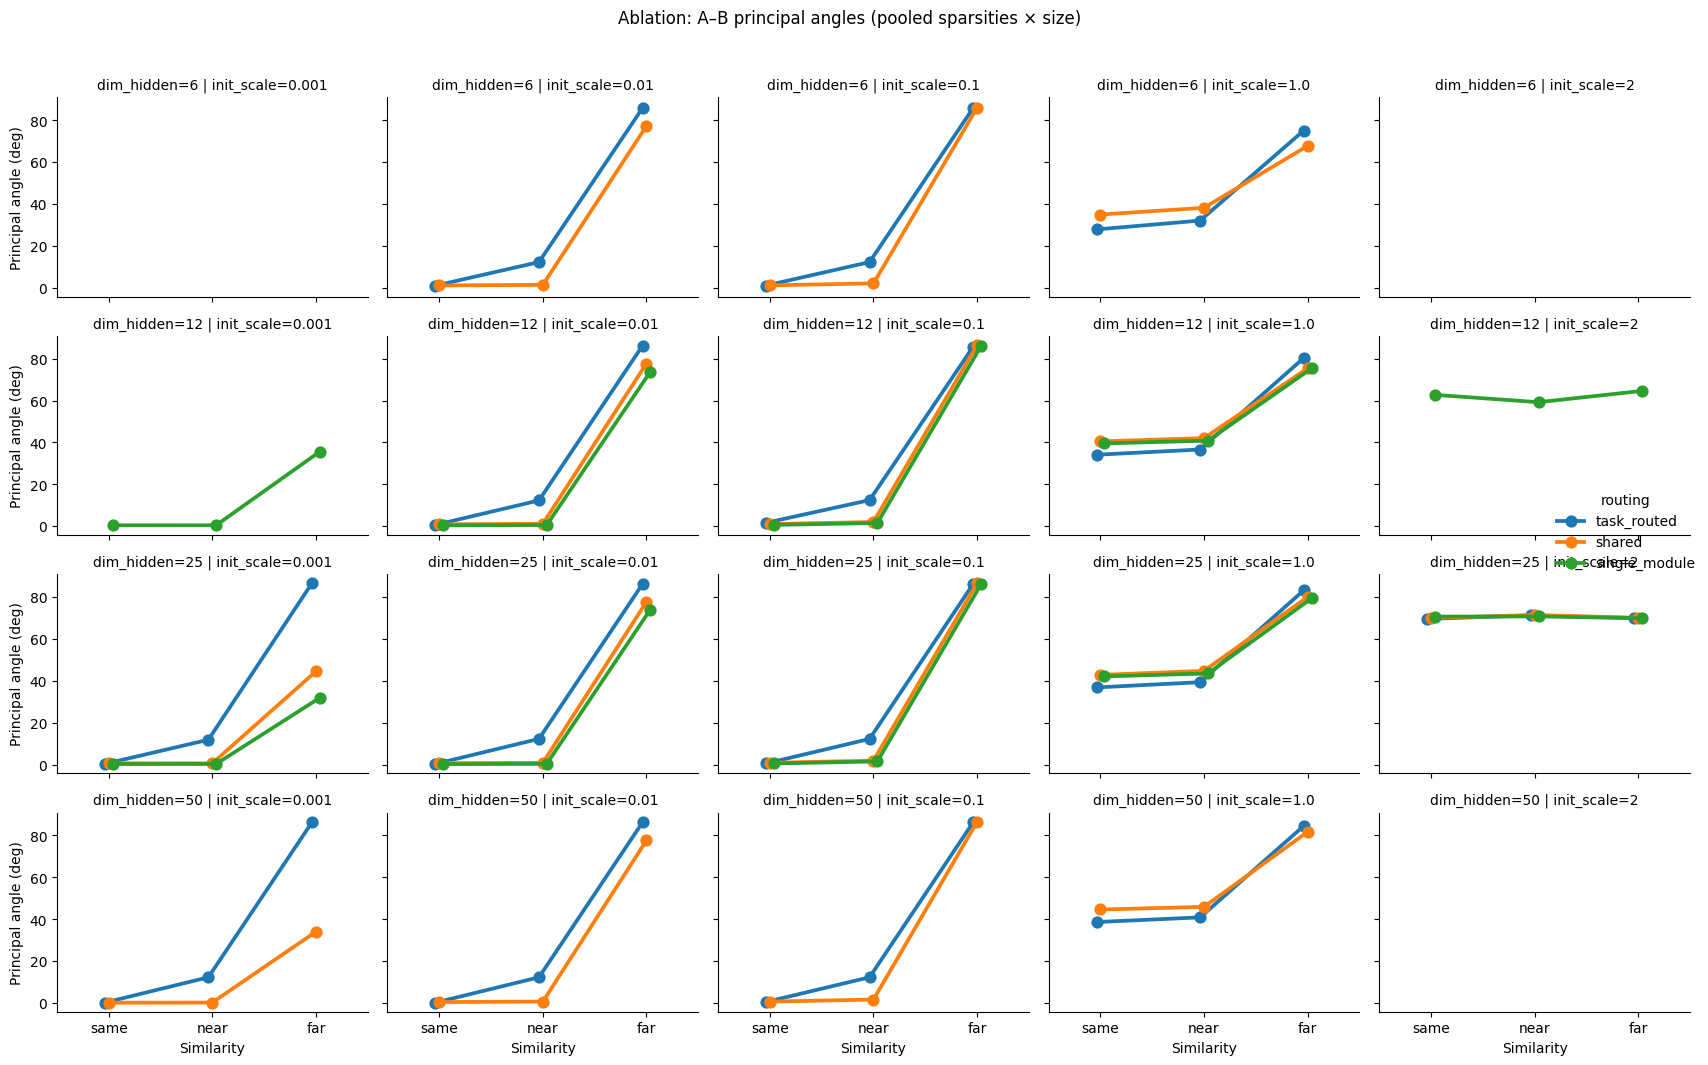

In [ ]:
def add_routing_label(df: pd.DataFrame, routing: str):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    out["routing"] = routing
    return out


_parts_tr = [
    add_routing_label(transfer_task, "task_routed"),
    add_routing_label(transfer_shared, "shared"),
]
if not transfer_single.empty:
    _parts_tr.append(add_routing_label(transfer_single, "single_module"))
tr_both = pd.concat(_parts_tr, ignore_index=True)

_parts_ang = [
    add_routing_label(angles_task, "task_routed"),
    add_routing_label(angles_shared, "shared"),
]
if not angles_single.empty:
    _parts_ang.append(add_routing_label(angles_single, "single_module"))
ang_both = pd.concat(_parts_ang, ignore_index=True)

if not tr_both.empty:
    g = sns.catplot(
        data=tr_both,
        x="condition",
        y="error_diff",
        hue="routing",
        col="init_scale",
        row="dim_hidden",
        col_order=init_order,
        row_order=dim_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "transfer_error_diff")
    g.set_titles(row_template="dim_hidden={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Ablation: paper-faithful transfer (pooled sparsities × size)", y=1.02)
    plt.tight_layout()
    plt.show()

if not ang_both.empty:
    ang_both["init_scale"] = ang_both["init_scale"].astype(float)
    g = sns.catplot(
        data=ang_both,
        x="condition",
        y="principal_angle_between",
        hue="routing",
        col="init_scale",
        row="dim_hidden",
        col_order=init_order,
        row_order=size_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.4,
        aspect=1.2,
        errorbar="se",
        capsize=0.08,
    )
    g.set_axis_labels("Similarity", "Principal angle (deg, ± SEM)")
    g.set_titles(row_template="size={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Ablation: A–B principal angles (pooled sparsities × size)", y=1.02)
    plt.tight_layout()
    plt.show()


## Appendix: paper-faithful transfer (winter, k=6)

Same pooling policy as other figures (**sparsities pooled**; **row = `dim_hidden`**). The next cell plots protocol `transfer_error_diff` via the notebook `error_diff` series (`compute_metrics`, winter slice `1::2`).



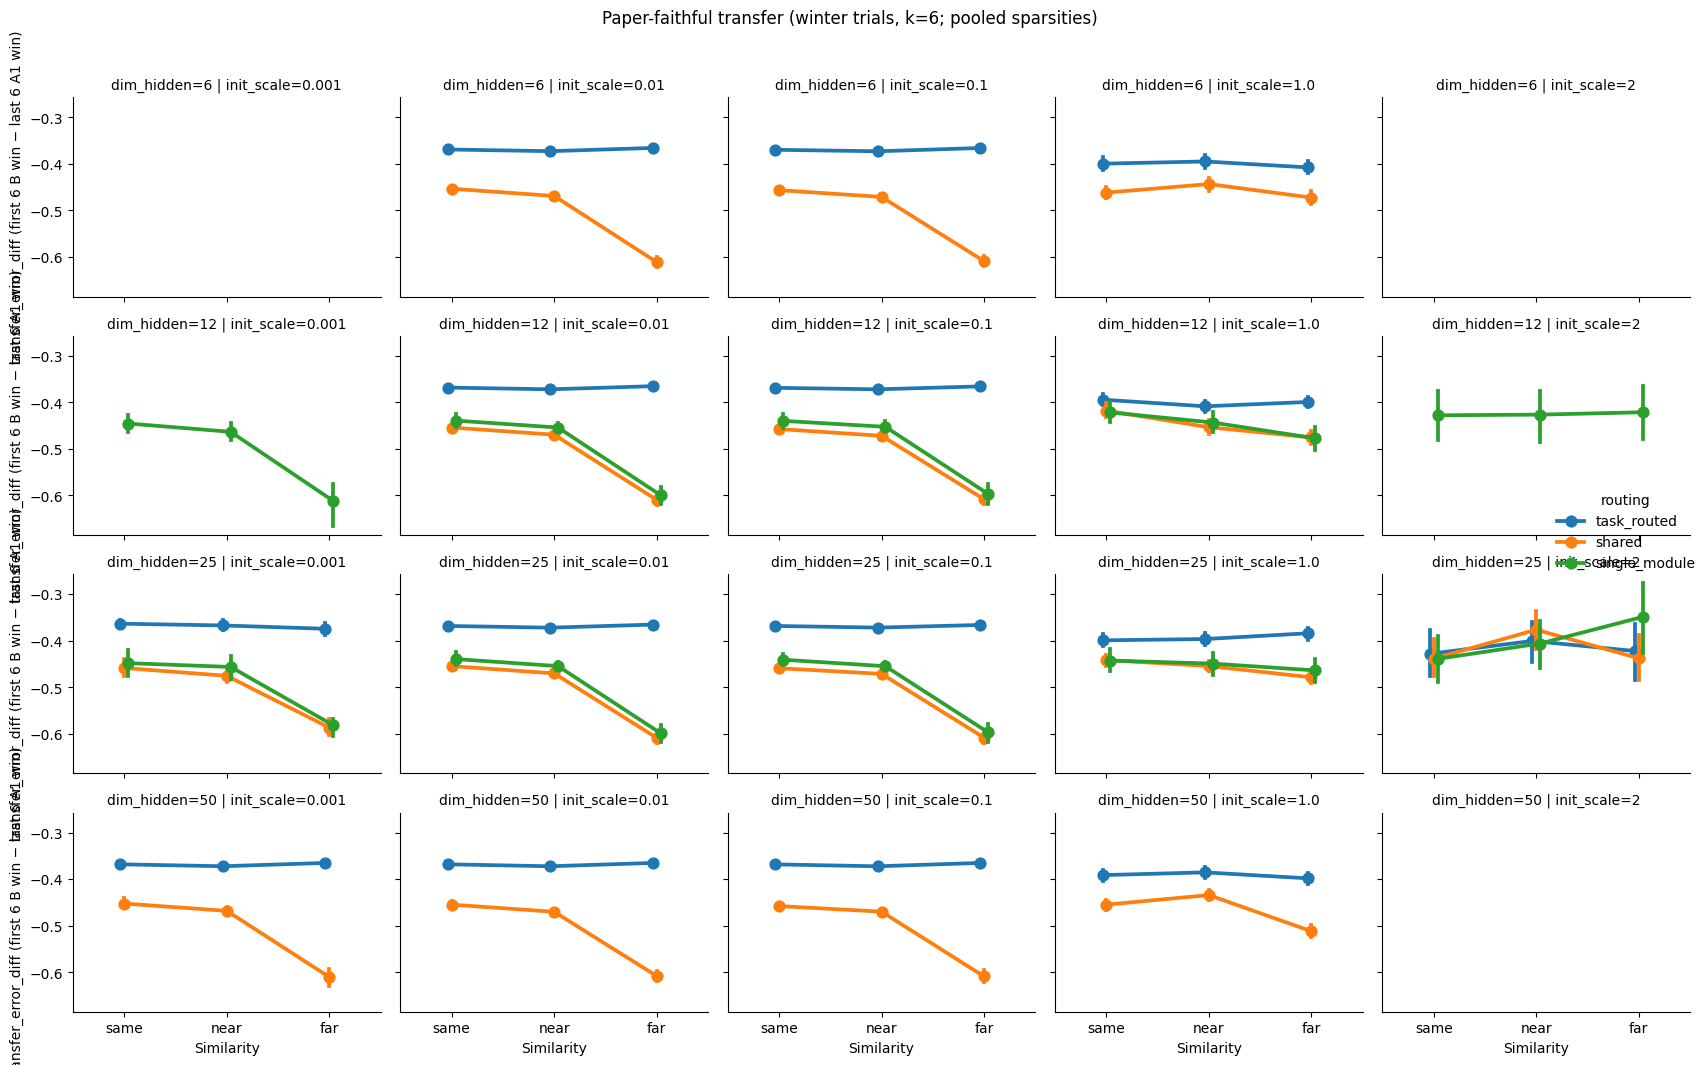

In [ ]:
# A.1 Paper-faithful transfer (winter, k=6; pooled sparsities × dim_hidden)

# PAPER_FAITHFUL_TESTING_PROTOCOL.md (Transfer):
# transfer_error_diff = mean(first 6 B winter) - mean(last 6 A1 winter)
# Same as `compute_metrics` column `error_diff` (winter slice accuracy[phase, 1::2]).

dim_order = list(SIZE_GRID)
protocol_tr = pd.concat(
    [
        add_routing_label(transfer_task, "task_routed"),
        add_routing_label(transfer_shared, "shared"),
        add_routing_label(transfer_single, "single_module"),
    ],
    ignore_index=True,
)

if not protocol_tr.empty:
    protocol_tr = protocol_tr.copy()
    protocol_tr["dim_hidden"] = pd.Categorical(protocol_tr["dim_hidden"], categories=SIZE_GRID, ordered=True)
    sub = protocol_tr[protocol_tr["init_scale"].isin(PAPER_INIT_SCALES)].copy()

    g = sns.catplot(
        data=sub,
        x="condition",
        y="error_diff",
        hue="routing",
        col="init_scale",
        row="dim_hidden",
        col_order=PAPER_INIT_SCALES,
        row_order=dim_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "transfer_error_diff (first 6 B win − last 6 A1 win)")
    g.set_titles(row_template="dim_hidden={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Paper-faithful transfer (winter trials, k=6; pooled sparsities)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No rows for paper-faithful transfer (error_diff).")

# Paper-faithful retest interference (von Mises: 1 - A_weight_A2)
def load_vonmises_size_comparison(df_runs: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    missing = []
    if df_runs is None or df_runs.empty:
        return pd.DataFrame(), pd.DataFrame()
    for _, row in df_runs.iterrows():
        run_id = row["run_id"]
        fit_path = sim_folder / f"{run_id}_vonmises_fits.csv"
        if not fit_path.exists():
            missing.append({
                "run_id": run_id,
                "dim_hidden": row["dim_hidden"],
                "init_scale": row["init_scale"],
                "routing": row.get("routing", "unknown"),
            })
            continue
        fit_df = pd.read_csv(fit_path).copy()
        required = {"participant", "condition", "A_weight_A2"}
        if not required.issubset(fit_df.columns):
            missing.append({
                "run_id": run_id,
                "dim_hidden": row["dim_hidden"],
                "init_scale": row["init_scale"],
                "routing": row.get("routing", "unknown"),
            })
            continue
        fit_df = fit_df[fit_df["condition"].isin(["near", "far"])].copy()
        if fit_df.empty:
            continue
        fit_df["dim_hidden"] = int(row["dim_hidden"])
        fit_df["init_scale"] = float(row["init_scale"])
        fit_df["routing"] = row.get("routing", "unknown")
        fit_df["interference"] = 1.0 - fit_df["A_weight_A2"].astype(float)
        rows.append(fit_df[["participant", "condition", "dim_hidden", "init_scale", "routing", "interference"]])
    return (
        pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(),
        pd.DataFrame(missing),
    )

vm_df, vm_missing = load_vonmises_size_comparison(df)
if not vm_missing.empty:
    display(
        vm_missing.groupby(["routing", "dim_hidden", "init_scale"], observed=True)
        .size()
        .rename("missing_fit_csvs")
        .reset_index()
        .sort_values(["routing", "dim_hidden", "init_scale"])
    )

if not vm_df.empty:
    vm_df["dim_hidden"] = pd.Categorical(vm_df["dim_hidden"], categories=size_order, ordered=True)
    vm_df["init_scale"] = pd.Categorical(vm_df["init_scale"], categories=init_order, ordered=True)
    g = sns.catplot(
        data=vm_df,
        x="condition",
        y="interference",
        hue="routing",
        row="dim_hidden",
        col="init_scale",
        kind="swarm",
        dodge=True,
        order=["near", "far"],
        hue_order=["task_routed", "shared"],
        palette=palette_routing,
        size=1.7,
        linewidth=0,
        alpha=0.85,
        height=2.55,
        aspect=1.05,
    )
    for i, dim_hidden in enumerate(size_order):
        for j, init_scale in enumerate(init_order):
            ax = g.axes[i, j]
            sub = vm_df[(vm_df["dim_hidden"] == dim_hidden) & (vm_df["init_scale"] == init_scale)]
            if sub.empty:
                continue
            sns.pointplot(
                data=sub,
                x="condition",
                y="interference",
                hue="routing",
                order=["near", "far"],
                hue_order=["task_routed", "shared"],
                palette=palette_routing,
                dodge=True,
                errorbar="se",
                capsize=0.08,
                markers="D",
                linestyles="",
                scale=0.55,
                legend=False,
                ax=ax,
            )
            sns.pointplot(
                data=sub,
                x="condition",
                y="interference",
                hue="routing",
                order=["near", "far"],
                hue_order=["task_routed", "shared"],
                palette=palette_routing,
                dodge=True,
                errorbar=None,
                markers="D",
                linestyles="-",
                scale=0.55,
                legend=False,
                ax=ax,
            )
    g.set_axis_labels("Similarity", "Retest interference\n$p$(Rule B)")
    g.set_titles(row_template="dim_hidden={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Paper-faithful retest interference (von Mises; sparsities pooled × size × init)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No von Mises fit CSVs available for pooled size-comparison interference.")


## Exploratory: Is there a sparsity effect, and does it interact with size/init/condition?

This section is diagnostic (not final-paper plotting). It keeps **task-routed participant-level rows unpooled by sparsity** and answers:

- Is there a visible main effect of sparsity on transfer?
- Does that effect depend on `dim_hidden`, `init_scale`, or similarity condition?

The first plot shows interaction trends across sparsity levels, and the second summarizes the contrast `1.0 - no_comms` for each `(dim_hidden, init_scale, condition)` cell.

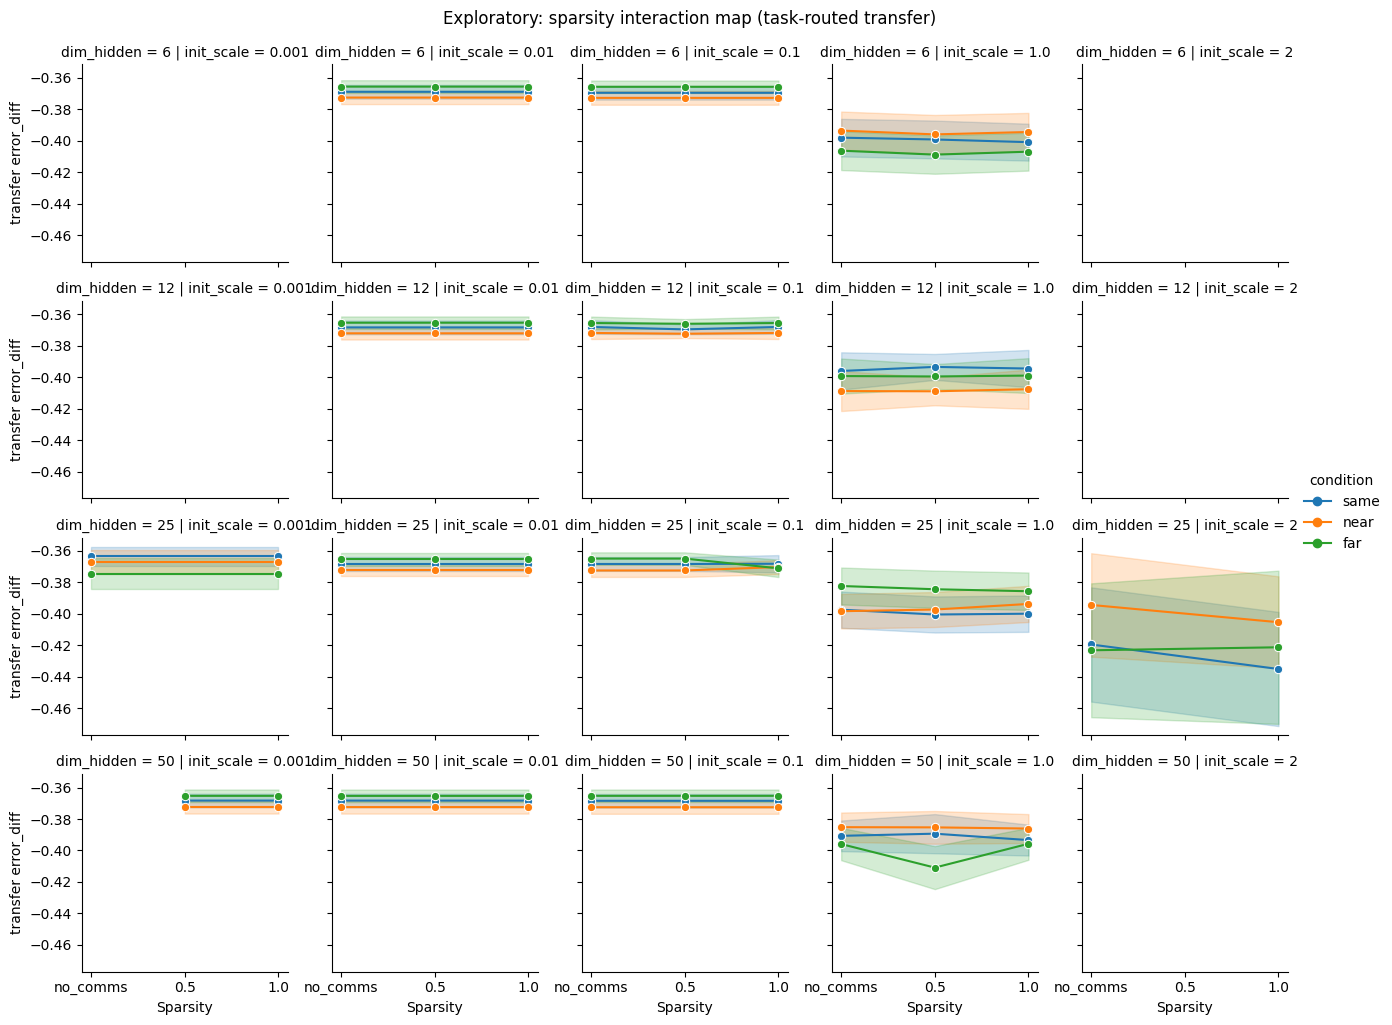

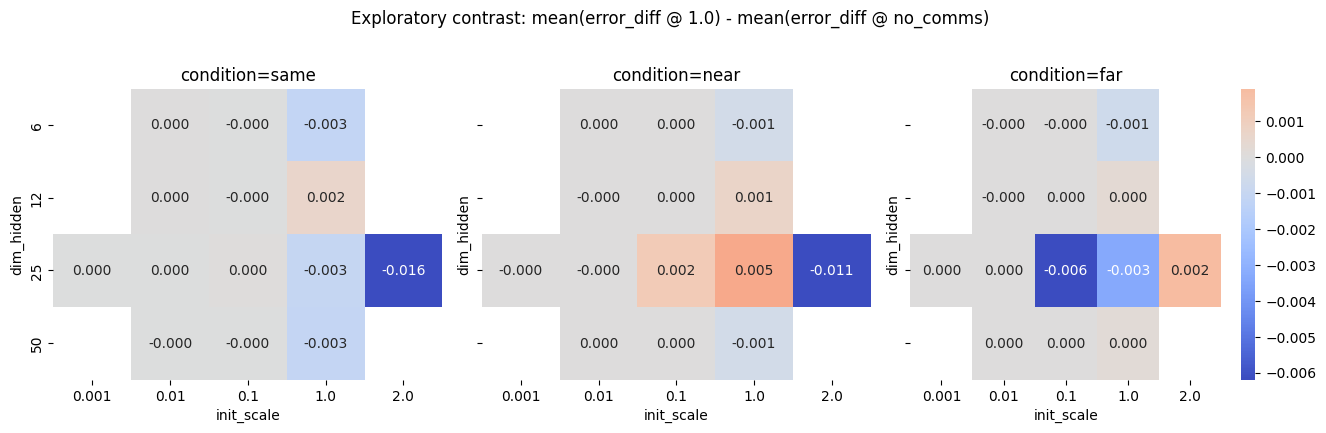

Top |sparsity contrast| cells (1.0 - no_comms):


sparsity_label,dim_hidden,init_scale,condition,delta_sp1_minus_nocomms,abs_delta
32,25,2.0,same,-0.015579,0.015579
31,25,2.0,near,-0.010977,0.010977
24,25,0.1,far,-0.006196,0.006196
28,25,1.0,near,0.004628,0.004628
27,25,1.0,far,-0.003329,0.003329
8,6,1.0,same,-0.002860,0.002860
44,50,1.0,same,-0.002696,0.002696
29,25,1.0,same,-0.002546,0.002546
25,25,0.1,near,0.002157,0.002157
30,25,2.0,far,0.001915,0.001915


In [ ]:
# Exploratory sparsity diagnostics on task-routed transfer metric

if transfer_task.empty:
    print("No task-routed transfer rows available.")
else:
    diag = transfer_task.copy()
    diag["init_scale"] = diag["init_scale"].astype(float)
    diag["sparsity_label"] = pd.Categorical(
        diag["sparsity_label"].astype(str),
        categories=PAPER_SPARSITIES,
        ordered=True,
    )

    dim_order_diag = sorted(diag["dim_hidden"].dropna().unique().tolist())
    init_order_diag = [x for x in PAPER_INIT_SCALES if x in set(diag["init_scale"].unique())]

    # (A) Interaction trends: mean +/- SEM across sparsity per condition
    g = sns.relplot(
        data=diag,
        x="sparsity_label",
        y="error_diff",
        hue="condition",
        hue_order=SIMILARITY_ORDER,
        kind="line",
        estimator="mean",
        errorbar="se",
        marker="o",
        dashes=False,
        row="dim_hidden",
        col="init_scale",
        row_order=dim_order_diag,
        col_order=init_order_diag,
        height=2.5,
        aspect=1.05,
    )
    g.set_axis_labels("Sparsity", "transfer error_diff")
    g.fig.suptitle("Exploratory: sparsity interaction map (task-routed transfer)", y=1.02)
    plt.show()

    # (B) Effect-size summary: contrast (1.0 - no_comms) by size/init/condition
    means = (
        diag.groupby(["dim_hidden", "init_scale", "condition", "sparsity_label"], observed=True)["error_diff"]
        .mean()
        .reset_index()
    )
    pivot = means.pivot_table(
        index=["dim_hidden", "init_scale", "condition"],
        columns="sparsity_label",
        values="error_diff",
        observed=True,
    ).reset_index()

    if {"1.0", "no_comms"}.issubset(set(pivot.columns)):
        pivot["delta_sp1_minus_nocomms"] = pivot["1.0"] - pivot["no_comms"]

        conds_present = [c for c in SIMILARITY_ORDER if c in set(pivot["condition"]) ]
        if not conds_present:
            conds_present = sorted(pivot["condition"].dropna().unique().tolist())

        fig, axes = plt.subplots(1, len(conds_present), figsize=(4.5 * len(conds_present), 4.2), sharey=True)
        if len(conds_present) == 1:
            axes = [axes]

        for ax, cond in zip(axes, conds_present):
            sub = pivot[pivot["condition"] == cond]
            mat = sub.pivot(index="dim_hidden", columns="init_scale", values="delta_sp1_minus_nocomms")
            mat = mat.reindex(index=dim_order_diag, columns=init_order_diag)
            sns.heatmap(
                mat,
                ax=ax,
                cmap="coolwarm",
                center=0.0,
                annot=True,
                fmt=".3f",
                cbar=(ax is axes[-1]),
            )
            ax.set_title(f"condition={cond}")
            ax.set_xlabel("init_scale")
            ax.set_ylabel("dim_hidden")

        fig.suptitle("Exploratory contrast: mean(error_diff @ 1.0) - mean(error_diff @ no_comms)", y=1.02)
        plt.tight_layout()
        plt.show()

        top_abs = (
            pivot[["dim_hidden", "init_scale", "condition", "delta_sp1_minus_nocomms"]]
            .assign(abs_delta=lambda d: d["delta_sp1_minus_nocomms"].abs())
            .sort_values("abs_delta", ascending=False)
            .head(10)
        )
        print("Top |sparsity contrast| cells (1.0 - no_comms):")
        display(top_abs)
    else:
        print("Could not compute 1.0 - no_comms contrast; required sparsity levels not both present.")